In [3]:
import re
import sys
from datetime import datetime, date, timedelta

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from termcolor import colored
from time import sleep

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

import statsmodels.api as sm
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np





#sys.stdout.reconfigure(encoding='utf-8')

teams = ["Diamondbacks", "Braves", "Orioles", "Red Sox", "Cubs", "White Sox",
            "Reds", "Guardians", "Rockies", "Tigers", "Astros", "Royals",
            "Angels", "Dodgers", "Marlins", "Brewers", "Twins", "Mets",
            "Yankees", "Athletics", "Phillies", "Pirates", "Padres", "Giants",
            "Mariners", "Cardinals", "Rays", "Rangers", "Blue Jays", "Nationals"]


### fcns

In [4]:
def check_team_names(team1, team2):
    if team1 == "D-backs" or team1 == "Arizona Diamondbacks":
        team1 = "Diamondbacks"
    elif team1 == "Atlanta Braves":
        team1 = "Braves"
    elif team1 == "Baltimore Orioles":
        team1 = "Orioles"
    elif team1 == "Boston Red Sox":
        team1 = "Red Sox"
    elif team1 == "Chicago Cubs":
        team1 = "Cubs"
    elif team1 == "Chicago White Sox":
        team1 = "White Sox"
    elif team1 == "Cincinnati Reds":
        team1 = "Reds"
    elif team1 == "Cleveland Guardians":
        team1 = "Guardians"
    elif team1 == "Colorado Rockies":
        team1 = "Rockies"
    elif team1 == "Detroit Tigers":
        team1 = "Tigers"
    elif team1 == "Houston Astros":
        team1 = "Astros"
    elif team1 == "Kansas City Royals":
        team1 = "Royals"
    elif team1 == "Los Angeles Angels":
        team1 = "Angels"
    elif team1 == "Los Angeles Dodgers":
        team1 = "Dodgers"
    elif team1 == "Miami Marlins":
        team1 = "Marlins"
    elif team1 == "Milwaukee Brewers":
        team1 = "Brewers"
    elif team1 == "Minnesota Twins":
        team1 = "Twins"
    elif team1 == "New York Mets":
        team1 = "Mets"
    elif team1 == "New York Yankees":
        team1 = "Yankees"
    elif team1 == "Philadelphia Phillies":
        team1 = "Phillies"
    elif team1 == "Pittsburgh Pirates":
        team1 = "Pirates"
    elif team1 == "San Diego Padres":
        team1 = "Padres"
    elif team1 == "San Francisco Giants":
        team1 = "Giants"
    elif team1 == "Seattle Mariners":
        team1 = "Mariners"
    elif team1 == "St. Louis Cardinals":
        team1 = "Cardinals"
    elif team1 == "Tampa Bay Rays":
        team1 = "Rays"
    elif team1 == "Texas Rangers":
        team1 = "Rangers"
    elif team1 == "Toronto Blue Jays":
        team1 = "Blue Jays"
    elif team1 == "Washington Nationals":
        team1 = "Nationals"

    if team2 == "D-backs" or team2 == "Arizona Diamondbacks":
        team2 = "Diamondbacks"
    elif team2 == "Atlanta Braves":
        team2 = "Braves"
    elif team2 == "Baltimore Orioles":
        team2 = "Orioles"
    elif team2 == "Boston Red Sox":
        team2 = "Red Sox"
    elif team2 == "Chicago Cubs":
        team2 = "Cubs"
    elif team2 == "Chicago White Sox":
        team2 = "White Sox"
    elif team2 == "Cincinnati Reds":
        team2 = "Reds"
    elif team2 == "Cleveland Guardians":
        team2 = "Guardians"
    elif team2 == "Colorado Rockies":
        team2 = "Rockies"
    elif team2 == "Detroit Tigers":
        team2 = "Tigers"
    elif team2 == "Houston Astros":
        team2 = "Astros"
    elif team2 == "Kansas City Royals":
        team2 = "Royals"
    elif team2 == "Los Angeles Angels":
        team2 = "Angels"
    elif team2 == "Los Angeles Dodgers":
        team2 = "Dodgers"
    elif team2 == "Miami Marlins":
        team2 = "Marlins"
    elif team2 == "Milwaukee Brewers":
        team2 = "Brewers"
    elif team2 == "Minnesota Twins":
        team2 = "Twins"
    elif team2 == "New York Mets":
        team2 = "Mets"
    elif team2 == "New York Yankees":
        team2 = "Yankees"
    elif team2 == "Philadelphia Phillies":
        team2 = "Phillies"
    elif team2 == "Pittsburgh Pirates":
        team2 = "Pirates"
    elif team2 == "San Diego Padres":
        team2 = "Padres"
    elif team2 == "San Francisco Giants":
        team2 = "Giants"
    elif team2 == "Seattle Mariners":
        team2 = "Mariners"
    elif team2 == "St. Louis Cardinals":
        team2 = "Cardinals"
    elif team2 == "Tampa Bay Rays":
        team2 = "Rays"
    elif team2 == "Texas Rangers":
        team2 = "Rangers"
    elif team2 == "Toronto Blue Jays":
        team2 = "Blue Jays"
    elif team2 == "Washington Nationals":
        team2 = "Nationals"

    return team1, team2

In [815]:
from datetime import datetime
from typing import Any

import requests


BASE_URL = "https://statsapi.mlb.com/api/v1"
TIMEOUT_SECONDS = 20


def get_json(url: str, params: dict[str, Any] | None = None) -> dict:
    """Send a GET request and return the JSON response."""
    response = requests.get(
        url,
        params=params,
        timeout=TIMEOUT_SECONDS
    )
    response.raise_for_status()
    return response.json()


def find_pitcher_id(pitcher_name: str) -> tuple[int, str]:
    """
    Find a player's MLB ID using their name.

    Returns:
        (player_id, full_name)
    """
    url = f"{BASE_URL}/people/search"

    data = get_json(
        url,
        params={
            "names": pitcher_name,
            "sportIds": 1
        }
    )

    people = data.get("people", [])

    if not people:
        raise ValueError(f'No MLB player found for "{pitcher_name}".')

    # Prefer an exact name match.
    exact_matches = [
        player
        for player in people
        if player.get("fullName", "").lower() == pitcher_name.lower()
    ]

    player = exact_matches[0] if exact_matches else people[0]

    return player["id"], player["fullName"]

def get_season_game_logs(
    player_id: int,
    season: int,
    cache: dict
) -> list[dict[str, Any]]:
    """
    Return one season of pitching game logs.

    If that season was already fetched during this script run,
    reuse the cached response instead of calling the API again.
    """
    cache_key = (player_id, season)

    if cache_key in cache:
        return cache[cache_key]

    url = f"{BASE_URL}/people/{player_id}/stats"

    data = get_json(
        url,
        params={
            "stats": "gameLog",
            "group": "pitching",
            "season": season,
            "gameType": "R"
        }
    )

    stats_groups = data.get("stats", [])

    if not stats_groups:
        game_logs = []
    else:
        game_logs = stats_groups[0].get("splits", [])

    cache[cache_key] = game_logs

    return game_logs

def get_team_record(team_name, target_date):
    """
    Returns a team's record entering the given date.

    team_name: Full team name (e.g. "Toronto Blue Jays")
    target_date: MM-DD-YYYY
    """

    target_date = datetime.strptime(
        target_date,
        "%m-%d-%Y"
    )

    standings_date = target_date - timedelta(days=1)
    season = target_date.year

    # Standings as of the beginning of this day
    response = requests.get(
        f"{BASE_URL}/standings",
        params={
            "leagueId": "103,104",
            "season": season,
            "date": standings_date.strftime("%Y-%m-%d")
        },
        timeout=30
    )
    response.raise_for_status()

    data = response.json()

    for division in data["records"]:
        for team in division["teamRecords"]:
            api_team, requested_team = check_team_names(team["team"]["name"], team_name)
            if api_team == requested_team:
                wins = int(team["leagueRecord"]["wins"])
                losses = int(team["leagueRecord"]["losses"])

                return {
                    "team": team["team"]["name"],
                    "wins": wins,
                    "losses": losses,
                    "record": f"({wins}-{losses})"
                }

    raise ValueError(f'Team "{team_name}" not found.')

def innings_to_outs(innings_pitched: str) -> int:
    """
    Convert MLB innings notation into outs.

    Examples:
        "6.0" -> 18 outs
        "5.1" -> 16 outs
        "5.2" -> 17 outs
    """
    whole_innings, partial_inning = innings_pitched.split(".")

    whole_innings = int(whole_innings)
    partial_inning = int(partial_inning)

    if partial_inning not in (0, 1, 2):
        raise ValueError(
            f"Unexpected innings-pitched value: {innings_pitched}"
        )

    return whole_innings * 3 + partial_inning

def get_starting_pitchers(
    team_name: str,
    target_date: str
) -> list[dict[str, Any]]:
    """
    Return the actual starting pitcher for each game played by a team
    on a historical date.

    Always returns a list:
        - one item for a normal game
        - two items for a doubleheader
    """
    parsed_date = parse_date(target_date)
    date_string = parsed_date

    # Find the team.
    teams_data = get_json(
        f"{BASE_URL}/teams",
        params={
            "sportId": 1,
            "season": parsed_date.year
        }
    )

    search_name = team_name.strip().lower()

    matching_teams = [
        team
        for team in teams_data["teams"]
        if search_name in {
            team.get("name", "").lower(),
            team.get("teamName", "").lower(),
            team.get("clubName", "").lower(),
            team.get("shortName", "").lower(),
            team.get("abbreviation", "").lower()
        }
        or search_name in team.get("name", "").lower()
    ]

    if not matching_teams:
        raise ValueError(f'No MLB team found for "{team_name}".')

    team = matching_teams[0]
    team_id = team["id"]
    full_team_name = team["name"]

    # Get the team's game or games on that date.
    schedule = get_json(
        f"{BASE_URL}/schedule",
        params={
            "sportId": 1,
            "teamId": team_id,
            "date": date_string,
            "gameType": "R"
        }
    )

    games = schedule["dates"][0]["games"]
    results = []

    for game in games:
        game_pk = game["gamePk"]

        side = (
            "home"
            if game["teams"]["home"]["team"]["id"] == team_id
            else "away"
        )

        opponent_side = "away" if side == "home" else "home"

        opponent = (
            game["teams"][opponent_side]["team"]["name"]
        )

        boxscore = get_json(
            f"{BASE_URL}/game/{game_pk}/boxscore"
        )

        team_boxscore = boxscore["teams"][side]

        # Pitchers are listed in order of appearance.
        starter_id = team_boxscore["pitchers"][0]
        starter = team_boxscore["players"][f"ID{starter_id}"]

        results.append(
            {
                "team": full_team_name,
                "date": date_string,
                "game_number": game.get("gameNumber", 1),
                "pitcher": starter["person"]["fullName"],
                "pitcher_id": starter_id,
                "opponent": opponent,
                "home_away": side,
                "game_pk": game_pk
            }
        )

    return results

def get_pitcher_era(
    pitcher_name: str,
    target_date: str,
    include_target_date: bool = True,
    cache: dict | None = None
) -> dict[str, Any]:
    """
    Calculate a pitcher's regular-season ERA as of a specified date.

    Args:
        pitcher_name:
            Example: "Dylan Cease"

        target_date:
            Accepts formats such as:
            "5/5/2026"
            "05/05/2026"
            "2026-05-05"
            "05-05-2026"

        include_target_date:
            True:
                Includes an appearance made on target_date.

            False:
                Returns the pitcher's ERA entering target_date.
                This is normally preferable for predictive modeling.

    Returns:
        Dictionary containing ERA, innings, earned runs, and appearances.
    """
    if cache is None:
        cache = {}

    parsed_date = parse_date(target_date)
    season = parsed_date.year

    player_id, full_name = find_pitcher_id(pitcher_name)

    game_logs = get_season_game_logs(
        player_id=player_id,
        season=season,
        cache=cache
    )

    if not game_logs:
        raise ValueError(
            f"No {season} regular-season pitching game log was found "
            f"for {full_name}."
        )

    total_outs = 0
    total_earned_runs = 0
    appearances = 0
    included_games = []

    for game in game_logs:
        game_date_string = game.get("date")

        if not game_date_string:
            continue

        game_date = datetime.strptime(
            game_date_string,
            "%Y-%m-%d"
        ).date()

        if include_target_date:
            should_include = game_date <= parsed_date
        else:
            should_include = game_date < parsed_date

        if not should_include:
            continue

        game_stats = game.get("stat", {})

        innings_pitched = game_stats.get("inningsPitched", "0.0")
        earned_runs = int(game_stats.get("earnedRuns", 0))

        outs = innings_to_outs(innings_pitched)

        total_outs += outs
        total_earned_runs += earned_runs
        appearances += 1

        included_games.append(
            {
                "date": game_date_string,
                "innings_pitched": innings_pitched,
                "earned_runs": earned_runs
            }
        )

    if total_outs == 0:
        return {
            "pitcher": full_name,
            "player_id": player_id,
            "date": parsed_date,
            "season": season,
            "era": None,
            "innings_pitched": "0.0",
            "earned_runs": 0,
            "appearances": 0,
            "message": (
                f"{full_name} had not recorded an out in {season} before "
                f"{parsed_date}."
            ),
            "games": []
        }

    # ERA = ER * 27 / outs
    era = total_earned_runs * 27 / total_outs

    return {
        "pitcher": full_name,
        "player_id": player_id,
        "date": parsed_date,
        "season": season,
        "era": round(era, 2),
        "innings_pitched": outs_to_innings(total_outs),
        "earned_runs": total_earned_runs,
        "appearances": appearances,
        "games": included_games
    }

def get_last_x_innings_era(
    pitcher_name: str,
    target_date: str,
    innings: int = 30,
    include_target_date: bool = False,
    cache: dict | None = None,
    max_seasons_back: int = 5
) -> dict[str, Any]:
    """
    Calculate ERA over a pitcher's most recent X innings.

    The function starts with the target season and only fetches
    previous seasons when more innings are needed.

    Complete appearances are used, so requesting 30 innings may
    return slightly more than 30 innings.
    """
    if cache is None:
        cache = {}

    parsed_date = parse_date(target_date)
    target_season = parsed_date.year
    required_outs = innings * 3

    player_id, full_name = find_pitcher_id(pitcher_name)

    eligible_games = []
    available_outs = 0
    season = target_season
    oldest_season = target_season - max_seasons_back

    while available_outs < required_outs and season >= oldest_season:
        game_logs = get_season_game_logs(
            player_id=player_id,
            season=season,
            cache=cache
        )

        for game in game_logs:
            game_date_string = game.get("date")

            if not game_date_string:
                continue

            game_date = datetime.strptime(
                game_date_string,
                "%Y-%m-%d"
            ).date()

            if include_target_date:
                should_include = game_date <= parsed_date
            else:
                should_include = game_date < parsed_date

            if not should_include:
                continue

            game_stats = game.get("stat", {})
            innings_pitched = game_stats.get(
                "inningsPitched",
                "0.0"
            )

            outs = innings_to_outs(innings_pitched)

            if outs == 0:
                continue

            eligible_games.append(
                {
                    "date": game_date,
                    "date_string": game_date_string,
                    "season": season,
                    "stat": game_stats
                }
            )

            available_outs += outs

        # Only fetch an earlier season if the games gathered so far
        # do not contain enough innings.
        season -= 1

    eligible_games.sort(
        key=lambda game: game["date"],
        reverse=True
    )

    total_outs = 0
    total_earned_runs = 0
    appearances = 0
    included_games = []

    for game in eligible_games:
        game_stats = game["stat"]

        innings_pitched = game_stats.get(
            "inningsPitched",
            "0.0"
        )

        earned_runs = int(
            game_stats.get("earnedRuns", 0)
        )

        outs = innings_to_outs(innings_pitched)

        total_outs += outs
        total_earned_runs += earned_runs
        appearances += 1

        included_games.append(
            {
                "date": game["date_string"],
                "season": game["season"],
                "innings_pitched": innings_pitched,
                "earned_runs": earned_runs
            }
        )

        if total_outs >= required_outs:
            break

    if total_outs == 0:
        return {
            "pitcher": full_name,
            "player_id": player_id,
            "date": parsed_date,
            "requested_innings": innings,
            "era": None,
            "innings_pitched": "0.0",
            "earned_runs": 0,
            "appearances": 0,
            "message": (
                f"{full_name} had not recorded any MLB outs before "
                f"{parsed_date}."
            ),
            "games": []
        }

    era = total_earned_runs * 27 / total_outs

    return {
        "pitcher": full_name,
        "player_id": player_id,
        "date": parsed_date,
        "requested_innings": innings,
        "era": round(era, 2),
        "innings_pitched": outs_to_innings(total_outs),
        "earned_runs": total_earned_runs,
        "appearances": appearances,
        "games": included_games
    }

def parse_date(date_string: str):
    """Parse either M/D/YYYY or YYYY-MM-DD or MM-DD-YYYY."""
    accepted_formats = (
        "%m/%d/%Y",
        "%Y-%m-%d",
        "%m-%d-%Y"
    )

    for date_format in accepted_formats:
        try:
            return datetime.strptime(
                date_string,
                date_format
            ).date()
        except ValueError:
            continue

    raise ValueError(
        "Date must be entered as M/D/YYYY or YYYY-MM-DD."
    )


def outs_to_innings(total_outs: int) -> str:
    """Convert outs back to standard MLB innings notation."""
    full_innings = total_outs // 3
    remaining_outs = total_outs % 3
    return f"{full_innings}.{remaining_outs}"




In [758]:
def fix_pregame_records(input_df):
    """
    Fixes lookahead in the 'Win %' and 'Opponent Win %' columns by removing
    the current game's result from both records.

    Doubleheader rows are skipped because Date + Team + Opponent is not unique.

    Required columns:
        Date
        Team
        Opponent
        Score
        Win %
        Opponent Win %

    Returns:
        A corrected copy of the DataFrame.
    """
    df = input_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    # Flag doubleheaders
    df["Matchup Count"] = (
        df.groupby(["Date", "Team", "Opponent"])["Team"]
            .transform("size")
    )

    normal_game = df["Matchup Count"] == 1

    # Build lookup for opponent scores
    opponent_lookup = (
        df.loc[normal_game, ["Date", "Team", "Score"]]
            .rename(columns={
                "Team": "Opponent",
                "Score": "Opponent Score"
            })
    )

    df = df.merge(
        opponent_lookup,
        on=["Date", "Opponent"],
        how="left",
        sort=False
    )

    valid_game = (
        (df["Matchup Count"] == 1)
        & df["Opponent Score"].notna()
    )

    # Parse team's record
    team_record_parts = (
        df["Win %"]
            .str.strip("()")
            .str.split("-", expand=True)
            .astype(int)
    )

    df["Team Wins"] = team_record_parts[0]
    df["Team Losses"] = team_record_parts[1]

    # Parse opponent's record
    opponent_record_parts = (
        df["Opponent Win %"]
            .str.strip("()")
            .str.split("-", expand=True)
            .astype(int)
    )

    df["Opponent Wins"] = opponent_record_parts[0]
    df["Opponent Losses"] = opponent_record_parts[1]

    team_won = valid_game & (df["Score"] > df["Opponent Score"])
    team_lost = valid_game & (df["Score"] < df["Opponent Score"])

    # Remove current result from team record
    df.loc[team_won, "Team Wins"] -= 1
    df.loc[team_lost, "Team Losses"] -= 1

    # Remove current result from opponent record
    df.loc[team_won, "Opponent Losses"] -= 1
    df.loc[team_lost, "Opponent Wins"] -= 1

    # Rebuild both record columns
    df["Win %"] = (
        "("
        + df["Team Wins"].astype(str)
        + "-"
        + df["Team Losses"].astype(str)
        + ")"
    )

    df["Opponent Win %"] = (
        "("
        + df["Opponent Wins"].astype(str)
        + "-"
        + df["Opponent Losses"].astype(str)
        + ")"
    )

    # Remove helper columns
    df = df.drop(columns=[
        "Matchup Count",
        "Opponent Score",
        "Team Wins",
        "Team Losses",
        "Opponent Wins",
        "Opponent Losses"
    ])
    
    df["Date"] = df["Date"].dt.strftime("%m-%d-%Y")

    return df

In [1539]:
def get_pitcher_stats(final_matchups, rolling_innings, date): # not always format ['Braves', '(54-38)', 'A', 'Pirates', '(47-47)', 'Mitch Keller', 'RHP', 5.14, '-110', '10', '11', '1.017', '07-09-2026']
    matchups = final_matchups.copy()
    for match in matchups: #
        # print(match)

        # Exists only while this script is running.
        game_log_cache = {}

        try:
            season = get_pitcher_era(
                pitcher_name=match[5],
                target_date=date,
                include_target_date=False,
                cache=game_log_cache
            )

            last30 = get_last_x_innings_era(
                pitcher_name=match[5],
                target_date=date,
                innings=rolling_innings,
                include_target_date=False,
                cache=game_log_cache
            )

            match[7] = season["era"]
            match.append(season["appearances"])
            match.append(last30["era"])

            # print(f'Pitcher: {season["pitcher"]}')
            # print(f'Date: {season["date"]}')

            # print(f'{season["season"]} Season:')
            # print(f'    ERA: {season["era"]:.2f}')
            # print(f'    Innings pitched: {season["innings_pitched"]}')
            # print(f'    Earned runs: {season["earned_runs"]}')
            # print(f'    Appearances: {season["appearances"]}')

            # print(f'Last {rolling_innings} innings:')
            # print(f'    ERA: {last30["era"]:.2f}')
            # print(f'    Innings pitched: {last30["innings_pitched"]}')
            # print(f'    Earned runs: {last30["earned_runs"]}')
            # print(f'    Appearances: {last30["appearances"]}')

        except requests.RequestException as error:
            print(f"MLB API request failed: {error}")
            print("filling appearances and L30 with None")
            match.append(None)
            match.append(None)

        except ValueError as error:
            print(f"Error: {error}")
            print("filling appearances and L30 with None")
            match.append(None)
            match.append(None)

        except AttributeError as error:
            print(f"Error(likely tbd pitcher): {error}")
            print("filling appearances and L30 with None")
            match.append(None)
            match.append(None)

    return matchups


In [1533]:
# this function gets all of the pitchers and their stats for todays games
def get_pitchers(teams, date):
    # URL of the StatMuse page for today's games
    formatted = date.strftime("%Y-%m-%d")
    url = f"https://www.mlb.com/probable-pitchers/{formatted}"

    # Send a GET request to the URL
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
        "Accept-Language": "en-US,en;q=0.9"
    }
    f_count = 0
    response = requests.get(url, headers=headers)
    response.raise_for_status()

    # Check if the request was successful
    if response.status_code == 200:
        # print(response.status_code)
        soup = BeautifulSoup(response.content, 'html.parser')

        text_content = soup.get_text()
        cleaned_text = "\n".join(line.lstrip() for line in text_content.splitlines() if line.strip())
        # print(cleaned_text)
        lines = cleaned_text.splitlines()
        # print(lines)
        output = []
        output2 = []
        games = []

        # for teams in game:
        for i in range(len(lines) - 2):  # Stop 2 lines early to avoid index errors
            # print(lines[i])
            # print(lines[i+1])
            lines[i], lines[i+2] = check_team_names(lines[i], lines[i+2])
            relevant_lines = []
            # if (lines[i] == 'Rockies' or lines[i+2] == 'Rockies') and f_count >= 2:
            #     print("yes")
            #     continue
            # if (lines[i] == 'Rockies' or lines[i+2] == 'Rockies') and f_count < 2:
            #     f_count += 1
            #     print(f"f off: {f_count}")
            # Check for the pattern
            if lines[i].strip() in teams and lines[i+1].strip() == '@' and lines[i+2].strip() in teams:
                # print(teams)
                team1 =lines[i].strip()
                team2 = lines[i+2].strip()
                games.append([team1, team2])
                if i + 14 < len(lines) and lines[i+4].strip() != "warmup" and lines[i+7].split()[0] != "Makeup":
                    # if team1 == "Padres":
                    #     print(lines[i:i+15])
                    if lines[i+4] == 'PPD':
                        continue

                    if len(lines[i+7]) > 8:
                        if lines[i+4].lower() == 'delayed':
                            print('Delayed, ok')
                            relevant_lines = lines[i+5:i+11]
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+4].lower() == 'delay':
                            print('Delay, ok')
                            relevant_lines = lines[i+5:i+11]
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7].split()[0] == 'Follows':
                            print("here45, ok")
                            relevant_lines = lines[i+4:i+10]
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7].split()[0] == 'Moved':
                            print("Moved, ok")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7] == 'Lou Gehrig Day':
                            print("Lou gehrig")
                            print(lines[i:i+15])
                            if lines[i+9].lower() == 'tbd':
                                entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+10], lines[i+11], lines[i+12].split()[1]]
                                entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], None, None, "Nan"]
                            elif lines[i+12].lower() == 'tbd':
                                entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], None, None, "Nan"]
                                entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                            else:
                                entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                                entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7] == 'Roberto Clemente Day':
                            print("Rob clemente")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7] == 'Jackie Robinson Day':
                            print("Jackie rob")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7].split()[0:4] == ['MLB', 'Little', 'League', 'Classic']:
                            print("Little League Classic")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7].split()[0:3] == ['MLB', 'Speedway', 'Classic']:
                            print("MLB Speedway Classic")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7].split()[0:2] == ['Mexico', 'City']:
                            print("Mexico City Series")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        else:
                            print("here105, ok")
                            relevant_lines = lines[i:i+15]
                            # print(relevant_lines)
                            if lines[i+4] == 'TBD':
                                # print(lines)
                                entry1 = [team1, lines[i+3], 'A', team2, lines[i+9], lines[i+13], lines[i+14], lines[i+15].split()[1]]
                                entry2 = [team2, lines[i+9], 'H', team1, lines[i+3], lines[i+10], lines[i+11], lines[i+12].split()[1]]
                            elif lines[i+4] == 'SUSP':
                                entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                                entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                            elif lines[i+7].split()[-1].lower() == 'opener' or lines[i+7].split()[-1].lower() == 'ppd':
                                entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                                entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                            elif lines[i+4] == 'final':
                                entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                                entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                            elif lines[i+7].lower() == 'in las vegas':
                                if lines[i+9] == 'TBD':
                                    entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+10], lines[i+11], lines[i+12].split()[1]]
                                    entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], None, None, "Nan"]
                                else:
                                    entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                                    entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                            else:
                                print(relevant_lines)
                                entry1 = [team1, lines[i+3], 'A', team2, lines[i+7], lines[i+11], lines[i+12], lines[i+13].split()[1]]
                                entry2 = [team2, lines[i+7], 'H', team1, lines[i+3], lines[i+8], lines[i+9], lines[i+10].split()[1]]

                        output.append([teams, relevant_lines])
                        
                    else:
                        relevant_lines = lines[i+8:i+14]
                        output.append([teams, relevant_lines])
                        print("here")
                        if lines[i+8] == 'TBD' and lines[i+9] == 'TBD':
                            # print(lines[i:i+12])
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+7], None, None, "Nan"]
                            entry2 = [team2, lines[i+7], 'H', team1, lines[i+3], None, None, "Nan"]
                        elif lines[i+8] == 'TBD':
                            # print(lines[i:i+12])
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+7], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                            entry2 = [team2, lines[i+7], 'H', team1, lines[i+3], None, None, "Nan"]
                        elif lines[i+11] == 'TBD':
                            # print(f"relevant lines: {relevant_lines}")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+7], None, None, "Nan"]
                            entry2 = [team2, lines[i+7], 'H', team1, lines[i+3], lines[i+8], lines[i+9], lines[i+10].split()[1]]
                            print(f"entry1: {entry1}")
                            print(f"entry2: {entry2}")
                        else:
                            # print(f"relevant lines else: {relevant_lines}")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+7], lines[i+11], lines[i+12], lines[i+13].split()[1]]
                            entry2 = [team2, lines[i+7], 'H', team1, lines[i+3], lines[i+8], lines[i+9], lines[i+10].split()[1]]
                else:
                    print("makeup eeee")
                    print(f"lines: {lines[i:i+15]}")
                    # print("makeup done")
                    if lines[i+4] == 'PPD':
                        continue
                    if len(lines[i+8]) > 10:
                        entry1 = [team1, lines[i+3], 'A', team2, lines[i+9], lines[i+13], lines[i+14], lines[i+15].split()[1]]
                        entry2 = [team2, lines[i+9], 'H', team1, lines[i+3], lines[i+10], lines[i+11], lines[i+12].split()[1]]
                    elif lines[i+7].split()[0].lower() == 'makeup':
                        print(lines[i:i+15])
                        if lines[i+9] == 'TBD':
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+10], lines[i+11], lines[i+12].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], None, None, "Nan"]
                        elif lines[i+12] == 'TBD':
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], None, None, "Nan"]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        else:
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                    else:
                        entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                        entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]

                # print(entry1)
                output2.append(entry1)
                output2.append(entry2)

        return output2, games

    else:
        print(date)
        print("probable pitchers")
        print(f"Failed to retrieve MLB webpage. Status code: {response.status_code}")



In [ ]:
def get_eras(opposing_pitchers, date, rolling_innings):
    updated_pitchers = []
    invalid_opps = []
    for p in opposing_pitchers:
        # year_str = date.strftime('%Y')
        try:
            # print(f"not going back for {p[5]}, converting: {p[-1]}, good")
            # print(p)
            # float(p[-1])

            # Exists only while this script is running.
            game_log_cache = {}

            try:
                season = get_pitcher_era(
                    pitcher_name=p[5],
                    target_date=date,
                    include_target_date=False,
                    cache=game_log_cache
                )

                last30 = get_last_x_innings_era(
                    pitcher_name=p[5],
                    target_date=date,
                    innings=rolling_innings,
                    include_target_date=False,
                    cache=game_log_cache
                )

                print(f'Pitcher: {season["pitcher"]}')
                print(f'Date: {season["date"]}')

                print(f'{season["season"]} Season:')
                print(f'    ERA: {season["era"]:.2f}')
                print(f'    Innings pitched: {season["innings_pitched"]}')
                print(f'    Earned runs: {season["earned_runs"]}')
                print(f'    Appearances: {season["appearances"]}')

                print(f'Last {rolling_innings} innings:')
                print(f'    ERA: {last30["era"]:.2f}')
                print(f'    Innings pitched: {last30["innings_pitched"]}')
                print(f'    Earned runs: {last30["earned_runs"]}')
                print(f'    Appearances: {last30["appearances"]}')

            except requests.RequestException as error:
                print(f"MLB API request failed: {error}")

            except ValueError as error:
                print(f"Error: {error}")
            
            updated_pitchers.append(p)
        except:
            year_str = str(date.year - 1)
            print(f"using prev year era for {p[5]}")
            print(p)

            url = f"https://www.statmuse.com/mlb/ask/{p[5]}-era-{year_str}-season"

            response = requests.get(url)

            # Check if the request was successful
            if response.status_code == 200:
                # print(response.status_code)
                soup = BeautifulSoup(response.content, 'html.parser')

                text_content = soup.get_text()
                lines = text_content.splitlines()
                relevant_line = lines[1]
                start_index = relevant_line.find('an ERA of')
                if start_index != -1:
                    end_index = start_index + len('an ERA of') + 10
                    era = relevant_line[start_index:end_index].split()[3]
                else:
                    print(f"error on {p[5]}")
                    print(relevant_line)
                    # if p[5] == 'Zach Thornton':
                    #     print("here")
                    #     era = 4.0
                    # else:
                    new_start_index = relevant_line.find(p[5], relevant_line.find(p[5]) + len(p[5]))
                    era = relevant_line[new_start_index:].split()[2 * len(p[5].split())]

                new_p = p.copy()
                # new_p.append(era)
                new_p[-1] = era
                updated_pitchers.append(new_p)
            else:
                print(f"cant find {p[5]}'s era page")
                invalid_opps.append(p[0])
                new_p = p.copy()
                # new_p.append(4)
                new_p[-1] = 4
                updated_pitchers.append(new_p)

    return updated_pitchers, invalid_opps



In [7]:
import json
def fetch_mlbodds_for_date(date):
    # 1) Get the scoreboard to discover each game’s IDs and team names
    formatted = date.strftime("%Y%m%d")

    sb_url = "https://site.api.espn.com/apis/site/v2/sports/baseball/mlb/scoreboard"
    sb = requests.get(sb_url, params={"dates": formatted}).json()

    out = []
    for event in sb.get("events", []):
        comp  = event["competitions"][0]
        
        teams = {t["homeAway"]: t["team"]["name"] for t in comp["competitors"]}
        # 2) Pull the core-API odds for that specific game
        odds_url = (
            "https://sports.core.api.espn.com/v2/"
            "sports/baseball/leagues/mlb/"
            f"events/{event['id']}/competitions/{comp['id']}/odds"
        )
        r = requests.get(odds_url)
        r.raise_for_status()
        j = r.json()
        # print(json.dumps(j, indent=2))  # inspect for a 'links' or 'markets' -> 'spreads' ref

        items = j.get("items", [])
        if not items:
            continue

        # 3) Take the first provider’s away/home money-line
        p         = items[0]
        away_ml   = p["awayTeamOdds"]["moneyLine"]
        home_ml   = p["homeTeamOdds"]["moneyLine"]
        away_ml_str  = f"{away_ml:+d}"   # e.g. "-160" or "+105"
        home_ml_str  = f"{home_ml:+d}"   # e.g. "+135" or "-120"

        # Spread line and odds
        try:
            away_spread      = p["awayTeamOdds"]["current"]["pointSpread"]["american"]
        except:
            away_spread      = None
        try:
            away_spread_odds = p["awayTeamOdds"]["current"]["spread"]["american"]
        except:
            away_spread_odds = None
        try:
            home_spread      = p["homeTeamOdds"]["current"]["pointSpread"]["american"]
        except:
            home_spread      = None
        try:
            home_spread_odds = p["homeTeamOdds"]["current"]["spread"]["american"]
        except:
            home_spread_odds = None

        total           = p["overUnder"]
        total_over      = p["overOdds"]
        total_under     = p["underOdds"]

        total_over_str = f"{int(total_over):+d}"
        total_under_str = f"{int(total_under):+d}"

        if away_spread_odds == "EVEN":
            away_spread_odds = +100
        if home_spread_odds == "EVEN":
            home_spread_odds = +100

        out.append((
            teams["away"], teams["home"],
            away_ml_str, home_ml_str,
            away_spread, home_spread,
            away_spread_odds, home_spread_odds,
            total, total_over_str, total_under_str
        ))
        ## 0: away team,        1: home team
        ## 2: away ml,          3: home ml
        ## 4: away spread,      5: home spread
        ## 6: away spread odds, 7: home spread odds
        ## 8: total line,       9: over total odds,     10: under total odds

    return out


In [8]:
def combine_pitchers_and_odds(pitchers, odds):
    pitchers_2 = pitchers.copy()
    doubleheader = []
    spreads = []
    for p in pitchers_2:
        first_game = 0
        for matchup in odds:
            if p[0] == matchup[0]:
                if first_game == 0 and p[0] not in doubleheader:
                    first_game = 1
                    p.append(matchup[2])
                    ## 0: team, 1: ml, 2: spread, 3: spread odds, 4: total line, 5: over total odds, 6: under total odds
                    spreads.append((matchup[0], matchup[2], matchup[4], matchup[6], matchup[8], matchup[9], matchup[10]))
                elif first_game == 1 and p[0] not in doubleheader:
                    doubleheader.append(p[0])
                elif first_game == 0 and p[0] in doubleheader:
                    first_game = 1
                elif first_game == 1 and p[0] in doubleheader:
                    first_game = 1
                    p.append(matchup[2])
                    spreads.append((matchup[0], matchup[2], matchup[4], matchup[6], matchup[8], matchup[9], matchup[10]))
            elif p[0] == matchup[1]:
                if first_game == 0 and p[0] not in doubleheader:
                    first_game = 1
                    p.append(matchup[3])
                    spreads.append((matchup[1], matchup[3], matchup[5], matchup[7], matchup[8], matchup[9], matchup[10]))
                elif first_game == 1 and p[0] not in doubleheader:
                    doubleheader.append(p[0])
                elif first_game == 0 and p[0] in doubleheader:
                    first_game = 1
                elif first_game == 1 and p[0] in doubleheader:
                    first_game = 1
                    p.append(matchup[3])
                    spreads.append((matchup[1], matchup[3], matchup[5], matchup[7], matchup[8], matchup[9], matchup[10]))
    
    for p in pitchers_2:
        if len(p) == 8:
            p.append(None)


    
    return pitchers_2, doubleheader, spreads

In [9]:
def get_game_stats(matchups, date, doubleheaders):
    updated_matchups = []
    first_game = []
    for match in matchups:
        formatted = date.strftime("%m-%d-%Y")
        url = f"https://www.statmuse.com/mlb/ask?q={match[0].lower()}+vs+{match[3].lower()}+{formatted}"

        response = requests.get(url)

        # Check if the request was successful
        if response.status_code == 200:
            # print(response.status_code)
            soup = BeautifulSoup(response.content, 'html.parser')
            text_content = soup.get_text()
            # print(text_content)
            lines = text_content.splitlines()
            if len(lines) == 4:
                relevant_line = lines[1]
                # print(relevant_line)
                first_index_1 = relevant_line.find(f'{match[0]}')
                first_index_2 = relevant_line.find(f'{match[0].lower()}')
                if first_index_2 < first_index_1:
                    first_index = first_index_2
                else:
                    first_index = first_index_1
                second_index = relevant_line.find(f'{match[0]}', first_index + len(f'{match[0]}'))
                stats_line = relevant_line[second_index + len(f'{match[0]}'):].split()
                # print(stats_line)
                if match[0] in doubleheaders and match[0] in first_game:
                    if stats_line[29] == match[0]: # all shifted up for result & AB merged
                        doubleheader = match.copy()
                        doubleheader.append(stats_line[36])
                        doubleheader.append(stats_line[37])
                        doubleheader.append(stats_line[57])
                        doubleheader.append(formatted)
                        updated_matchups.append(doubleheader)
                    elif stats_line[29] + ' ' + stats_line[30] == match[0]:
                        doubleheader = match.copy()
                        doubleheader.append(stats_line[37])
                        doubleheader.append(stats_line[38])
                        doubleheader.append(stats_line[59])
                        doubleheader.append(formatted)
                        updated_matchups.append(doubleheader)
                    else:
                        doubleheader = match.copy()
                        doubleheader.append(stats_line[6])
                        doubleheader.append(stats_line[7])
                        doubleheader.append(stats_line[27])
                        doubleheader.append(formatted)
                        updated_matchups.append(doubleheader)
                else:
                    if match[0] in doubleheaders:
                        first_game.append(match[0])

                    updated_match = match.copy()
                    updated_match.append(stats_line[6])
                    updated_match.append(stats_line[7])
                    updated_match.append(stats_line[27])
                    updated_match.append(formatted)
                    updated_matchups.append(updated_match)
            else:
                print("uh oh, we made it out")
                relevant_line = lines[6]
                first_index = relevant_line.find('Team Stats')
                second_index = relevant_line.find('SLG', first_index)
                stats_line = relevant_line[first_index:second_index+10].split()
                if match[2] == 'A':
                    match.append(stats_line[6])
                    match.append(stats_line[9])
                    match.append(str(round(float(stats_line[-7]) + float(stats_line[-4]), 3)))
                    match.append(formatted)
                elif match[2] == 'H':
                    match.append(stats_line[8])
                    match.append(stats_line[11])
                    match.append(str(round(float(stats_line[-5]) + float(stats_line[-2]), 3)))
                    match.append(formatted)

        else:
            print("game stats")
            print(f"{match[0]} vs {match[3]}")
            print(date)
            print(f"Failed to retrieve MLB webpage. Status code: {response.status_code}")
            count = 0
            while response.status_code != 200:
                sleep(2)
                response = requests.get(url)
                count += 1
                if count > 10:
                    count = 0

                    break
                # Check if the request was successful
                if response.status_code == 200:
                    print(f"fixed. code: {response.status_code}")
                    soup = BeautifulSoup(response.content, 'html.parser')
                    text_content = soup.get_text()
                    lines = text_content.splitlines()
                    if len(lines) == 4:
                        relevant_line = lines[1]
                        print(relevant_line)
                        first_index_1 = relevant_line.find(f'{match[0]}')
                        first_index_2 = relevant_line.find(f'{match[0].lower()}')
                        if first_index_2 < first_index_1:
                            first_index = first_index_2
                        else:
                            first_index = first_index_1
                        second_index = relevant_line.find(f'{match[0]}', first_index + len(f'{match[0]}'))
                        stats_line = relevant_line[second_index + len(f'{match[0]}'):].split()

                        if match[0] in doubleheaders and match[0] in first_game:
                            if stats_line[30] == match[0]:
                                doubleheader = match.copy()
                                doubleheader.append(stats_line[38])
                                doubleheader.append(stats_line[39])
                                doubleheader.append(stats_line[59])
                                doubleheader.append(formatted)
                                updated_matchups.append(doubleheader)
                            elif stats_line[30] + ' ' + stats_line[31] == match[0]:
                                doubleheader = match.copy()
                                doubleheader.append(stats_line[39])
                                doubleheader.append(stats_line[40])
                                doubleheader.append(stats_line[60])
                                doubleheader.append(formatted)
                                updated_matchups.append(doubleheader)
                            else:
                                print("lets hope not")
                                print(match)
                        else:
                            if match[0] in doubleheaders:
                                first_game.append(match[0])
                            updated_match = match.copy()
                            updated_match.append(stats_line[7])
                            updated_match.append(stats_line[8])
                            updated_match.append(stats_line[28])
                            updated_match.append(formatted)
                            updated_matchups.append(updated_match)
                    else:
                        print("uh oh, we made it out 2")
                        relevant_line = lines[6]
                        first_index = relevant_line.find('Team Stats')
                        second_index = relevant_line.find('SLG', first_index)
                        stats_lie = relevant_line[first_index:second_index+10].split()
                        if match[2] == 'A':
                            match.append(stats_line[6])
                            match.append(stats_line[9])
                            match.append(str(round(float(stats_line[-7]) + float(stats_line[-4]), 3)))
                            match.append(formatted)
                        elif match[2] == 'H':
                            match.append(stats_line[8])
                            match.append(stats_line[11])
                            match.append(str(round(float(stats_line[-5]) + float(stats_line[-2]), 3)))
                            match.append(formatted)
                else:
                    print(f"still working. code: {response.status_code}")
                    

    return updated_matchups




In [10]:
def language_checks(bets):
    for i in range(len(bets)):
        try:
            me_lines = re.split(r"[-()]", bets.loc[i, 'Win %'])
            opp_lines = re.split(r"[-()]", bets.loc[i, 'Opponent Win %'])
        except:
            print(i)
            print(bets.loc[i, 'Win %'])
            continue
        if len(me_lines) < 4:
            if len(opp_lines) < 4:
                continue
            else:
                opp_denom = float(opp_lines[1]) + float(opp_lines[2])
                if opp_denom == 0:
                    bets.loc[i,'Opponent Win % #'] = 0
                else:
                    bets.loc[i,'Opponent Win % #'] = round(float(opp_lines[1]) / opp_denom, 3)
        else:
            me_denom = float(me_lines[1]) + float(me_lines[2])
            if me_denom == 0:
                bets.loc[i,'Win % #'] = 0
            else:
                bets.loc[i,'Win % #'] = round(float(me_lines[1]) / me_denom, 3)
            if len(opp_lines) < 4:
                continue
            else:
                opp_denom = float(opp_lines[1]) + float(opp_lines[2])
                if opp_denom == 0:
                    bets.loc[i,'Opponent Win % #'] = 0
                else:
                    bets.loc[i,'Opponent Win % #'] = round(float(opp_lines[1]) / opp_denom, 3)

    for i in range(len(bets)):
        if bets.loc[i, 'Location'] == 'H':
            bets.loc[i, 'Location'] = 1
        elif bets.loc[i, 'Location'] == 'A':
            bets.loc[i, 'Location'] = 0
        if bets.loc[i, 'Opposing Pitcher Hand'] == 'LHP':
            bets.loc[i, 'Opposing Pitcher Hand'] = 1
        elif bets.loc[i, 'Opposing Pitcher Hand'] == 'RHP':
            bets.loc[i, 'Opposing Pitcher Hand'] = 0

    for i in range(len(bets)):
        if bets.loc[i, 'Opposing Pitcher Hand'] == '右投手':
            bets.loc[i, 'Opposing Pitcher Hand'] = 0
        elif bets.loc[i, 'Opposing Pitcher Hand'] == '左投手':
            bets.loc[i, 'Opposing Pitcher Hand'] = 1
        elif bets.loc[i, 'Opposing Pitcher Hand'] == 'LD':
            bets.loc[i, 'Opposing Pitcher Hand'] = 0
        elif bets.loc[i, 'Opposing Pitcher Hand'] == 'LZ':
            bets.loc[i, 'Opposing Pitcher Hand'] = 1

    return bets

### change

In [ ]:
# df = pd.read_csv('era_record_entries_11.csv')
# del df['Unnamed: 0']
# df["Date"] = pd.to_datetime(df["Date"])
# cutoff = pd.Timestamp("05-01-2026")
# # yesterday_date = date_to_add.strftime("%m-%d-%y")
# # yesterday = archive[archive['Date'] == yesterday_date]

# df_2 = df[df['Date'] < cutoff]
# df_2.to_csv(f'daily_entries_fixed/fixed_entries_26_04_30.csv')

In [3318]:
month = 6
day = 17
# 2 days ago
start_date = datetime(2026, month, day-2)
# start_date = datetime(2026, 5, 31)
# yesterday
date_to_add = datetime(2026, month, day-1)
# date_to_add = datetime(2026, 5, 31)
# today(predicting day)
date_to_predict = datetime(2026, month, day)
rolling_innings = 30

### thresholds

In [845]:
########## Home Favorites
# Scores
home_fav_scores_pred_exp_diff = -0.1 # 0.0 # 0.7 # 0.6
home_fav_scores_pred_diff = -0.8 # -0.7 # -0.2
home_fav_scores_exp_diff = -0.6 # -0.5
# Win %
home_fav_win_pct_pred_exp_diff = -0.1 # -1.0 # -1.5
home_fav_win_pct_pred_diff = 51.5 # 50.5 # 50.0
home_fav_win_pct_exp_diff = 51.5 # 51.0 # 50.5 # 50.0

########## Away Favorites
# Scores
away_fav_scores_pred_exp_diff = 0.6 # 0.5
away_fav_scores_pred_diff = 1.6 # 1.3
away_fav_scores_exp_diff = 0.5 # 0.7 # 0.6
# Win %
away_fav_win_pct_pred_exp_diff = 1.0 # 0.0
away_fav_win_pct_pred_diff = 57.0 # 56.0 # 55.5
away_fav_win_pct_exp_diff = 51.5 # 54.0 # 50.0

########## Home Underdogs
# Scores
home_dog_scores_pred_exp_diff = 1.0 # 1.1 # 1.5
home_dog_scores_pred_diff = -0.1
home_dog_scores_exp_diff = 0.8
# Win %
home_dog_win_pct_pred_exp_diff = 85.0
home_dog_win_pct_pred_diff = 50.5
home_dog_win_pct_exp_diff = 47.0 # 47.5

########## Away Favorites
# Scores
away_dog_scores_pred_exp_diff = -2.0
away_dog_scores_pred_diff = 0.4
away_dog_scores_exp_diff = -1.0
# Win %
away_dog_win_pct_pred_exp_diff = 91.0 # 85.0
away_dog_win_pct_pred_diff = 50.5 # 51.5 # 51.0
away_dog_win_pct_exp_diff = 43.0 # 48.0


########## Overs
# over_6 = 0.8
over_7 = 0.3 # 0.2
over_8 = 0.1 # 0.7
# over_9 = 0.7
# over_10 = 0.7
# over_11 = 0.1

########## Unders
under_7 = -0.4
under_8 = -0.1
under_9 = -1.1 # -0.7
# under_10 = -1.8 # -1.2
# under_11 = -2.8

# remake dataset

### pitchers era

In [66]:
from datetime import datetime
from typing import Any

import requests


BASE_URL = "https://statsapi.mlb.com/api/v1"
TIMEOUT_SECONDS = 20


def get_json(url: str, params: dict[str, Any] | None = None) -> dict:
    """Send a GET request and return the JSON response."""
    response = requests.get(
        url,
        params=params,
        timeout=TIMEOUT_SECONDS
    )
    response.raise_for_status()
    return response.json()


def find_pitcher_id(pitcher_name: str) -> tuple[int, str]:
    """
    Find a player's MLB ID using their name.

    Returns:
        (player_id, full_name)
    """
    url = f"{BASE_URL}/people/search"

    data = get_json(
        url,
        params={
            "names": pitcher_name,
            "sportIds": 1
        }
    )

    people = data.get("people", [])

    if not people:
        raise ValueError(f'No MLB player found for "{pitcher_name}".')

    # Prefer an exact name match.
    exact_matches = [
        player
        for player in people
        if player.get("fullName", "").lower() == pitcher_name.lower()
    ]

    player = exact_matches[0] if exact_matches else people[0]

    return player["id"], player["fullName"]

def get_season_game_logs(
    player_id: int,
    season: int,
    cache: dict
) -> list[dict[str, Any]]:
    """
    Return one season of pitching game logs.

    If that season was already fetched during this script run,
    reuse the cached response instead of calling the API again.
    """
    cache_key = (player_id, season)

    if cache_key in cache:
        return cache[cache_key]

    url = f"{BASE_URL}/people/{player_id}/stats"

    data = get_json(
        url,
        params={
            "stats": "gameLog",
            "group": "pitching",
            "season": season,
            "gameType": "R"
        }
    )

    stats_groups = data.get("stats", [])

    if not stats_groups:
        game_logs = []
    else:
        game_logs = stats_groups[0].get("splits", [])

    cache[cache_key] = game_logs

    return game_logs


def innings_to_outs(innings_pitched: str) -> int:
    """
    Convert MLB innings notation into outs.

    Examples:
        "6.0" -> 18 outs
        "5.1" -> 16 outs
        "5.2" -> 17 outs
    """
    whole_innings, partial_inning = innings_pitched.split(".")

    whole_innings = int(whole_innings)
    partial_inning = int(partial_inning)

    if partial_inning not in (0, 1, 2):
        raise ValueError(
            f"Unexpected innings-pitched value: {innings_pitched}"
        )

    return whole_innings * 3 + partial_inning

def get_starting_pitchers(
    team_name: str,
    target_date: str
) -> list[dict[str, Any]]:
    """
    Return the actual starting pitcher for each game played by a team
    on a historical date.

    Always returns a list:
        - one item for a normal game
        - two items for a doubleheader
    """
    parsed_date = parse_date(target_date)
    date_string = parsed_date

    # Find the team.
    teams_data = get_json(
        f"{BASE_URL}/teams",
        params={
            "sportId": 1,
            "season": parsed_date.year
        }
    )

    search_name = team_name.strip().lower()

    matching_teams = [
        team
        for team in teams_data["teams"]
        if search_name in {
            team.get("name", "").lower(),
            team.get("teamName", "").lower(),
            team.get("clubName", "").lower(),
            team.get("shortName", "").lower(),
            team.get("abbreviation", "").lower()
        }
        or search_name in team.get("name", "").lower()
    ]

    if not matching_teams:
        raise ValueError(f'No MLB team found for "{team_name}".')

    team = matching_teams[0]
    team_id = team["id"]
    full_team_name = team["name"]

    # Get the team's game or games on that date.
    schedule = get_json(
        f"{BASE_URL}/schedule",
        params={
            "sportId": 1,
            "teamId": team_id,
            "date": date_string,
            "gameType": "R"
        }
    )

    games = schedule["dates"][0]["games"]
    results = []

    for game in games:
        game_pk = game["gamePk"]

        side = (
            "home"
            if game["teams"]["home"]["team"]["id"] == team_id
            else "away"
        )

        opponent_side = "away" if side == "home" else "home"

        opponent = (
            game["teams"][opponent_side]["team"]["name"]
        )

        boxscore = get_json(
            f"{BASE_URL}/game/{game_pk}/boxscore"
        )

        team_boxscore = boxscore["teams"][side]

        # Pitchers are listed in order of appearance.
        starter_id = team_boxscore["pitchers"][0]
        starter = team_boxscore["players"][f"ID{starter_id}"]

        results.append(
            {
                "team": full_team_name,
                "date": date_string,
                "game_number": game.get("gameNumber", 1),
                "pitcher": starter["person"]["fullName"],
                "pitcher_id": starter_id,
                "opponent": opponent,
                "home_away": side,
                "game_pk": game_pk
            }
        )

    return results

def get_pitcher_era(
    pitcher_name: str,
    target_date: str,
    include_target_date: bool = True,
    cache: dict | None = None
) -> dict[str, Any]:
    """
    Calculate a pitcher's regular-season ERA as of a specified date.

    Args:
        pitcher_name:
            Example: "Dylan Cease"

        target_date:
            Accepts formats such as:
            "5/5/2026"
            "05/05/2026"
            "2026-05-05"
            "05-05-2026"

        include_target_date:
            True:
                Includes an appearance made on target_date.

            False:
                Returns the pitcher's ERA entering target_date.
                This is normally preferable for predictive modeling.

    Returns:
        Dictionary containing ERA, innings, earned runs, and appearances.
    """
    if cache is None:
        cache = {}

    parsed_date = parse_date(target_date)
    season = parsed_date.year

    player_id, full_name = find_pitcher_id(pitcher_name)

    game_logs = get_season_game_logs(
        player_id=player_id,
        season=season,
        cache=cache
    )

    if not game_logs:
        raise ValueError(
            f"No {season} regular-season pitching game log was found "
            f"for {full_name}."
        )

    total_outs = 0
    total_earned_runs = 0
    appearances = 0
    included_games = []

    for game in game_logs:
        game_date_string = game.get("date")

        if not game_date_string:
            continue

        game_date = datetime.strptime(
            game_date_string,
            "%Y-%m-%d"
        ).date()

        if include_target_date:
            should_include = game_date <= parsed_date
        else:
            should_include = game_date < parsed_date

        if not should_include:
            continue

        game_stats = game.get("stat", {})

        innings_pitched = game_stats.get("inningsPitched", "0.0")
        earned_runs = int(game_stats.get("earnedRuns", 0))

        outs = innings_to_outs(innings_pitched)

        total_outs += outs
        total_earned_runs += earned_runs
        appearances += 1

        included_games.append(
            {
                "date": game_date_string,
                "innings_pitched": innings_pitched,
                "earned_runs": earned_runs
            }
        )

    if total_outs == 0:
        return {
            "pitcher": full_name,
            "player_id": player_id,
            "date": parsed_date,
            "season": season,
            "era": None,
            "innings_pitched": "0.0",
            "earned_runs": 0,
            "appearances": 0,
            "message": (
                f"{full_name} had not recorded an out in {season} before "
                f"{parsed_date}."
            ),
            "games": []
        }

    # ERA = ER * 27 / outs
    era = total_earned_runs * 27 / total_outs

    return {
        "pitcher": full_name,
        "player_id": player_id,
        "date": parsed_date,
        "season": season,
        "era": round(era, 2),
        "innings_pitched": outs_to_innings(total_outs),
        "earned_runs": total_earned_runs,
        "appearances": appearances,
        "games": included_games
    }

def get_last_x_innings_era(
    pitcher_name: str,
    target_date: str,
    innings: int = 30,
    include_target_date: bool = False,
    cache: dict | None = None,
    max_seasons_back: int = 5
) -> dict[str, Any]:
    """
    Calculate ERA over a pitcher's most recent X innings.

    The function starts with the target season and only fetches
    previous seasons when more innings are needed.

    Complete appearances are used, so requesting 30 innings may
    return slightly more than 30 innings.
    """
    if cache is None:
        cache = {}

    parsed_date = parse_date(target_date)
    target_season = parsed_date.year
    required_outs = innings * 3

    player_id, full_name = find_pitcher_id(pitcher_name)

    eligible_games = []
    available_outs = 0
    season = target_season
    oldest_season = target_season - max_seasons_back

    while available_outs < required_outs and season >= oldest_season:
        game_logs = get_season_game_logs(
            player_id=player_id,
            season=season,
            cache=cache
        )

        for game in game_logs:
            game_date_string = game.get("date")

            if not game_date_string:
                continue

            game_date = datetime.strptime(
                game_date_string,
                "%Y-%m-%d"
            ).date()

            if include_target_date:
                should_include = game_date <= parsed_date
            else:
                should_include = game_date < parsed_date

            if not should_include:
                continue

            game_stats = game.get("stat", {})
            innings_pitched = game_stats.get(
                "inningsPitched",
                "0.0"
            )

            outs = innings_to_outs(innings_pitched)

            if outs == 0:
                continue

            eligible_games.append(
                {
                    "date": game_date,
                    "date_string": game_date_string,
                    "season": season,
                    "stat": game_stats
                }
            )

            available_outs += outs

        # Only fetch an earlier season if the games gathered so far
        # do not contain enough innings.
        season -= 1

    eligible_games.sort(
        key=lambda game: game["date"],
        reverse=True
    )

    total_outs = 0
    total_earned_runs = 0
    appearances = 0
    included_games = []

    for game in eligible_games:
        game_stats = game["stat"]

        innings_pitched = game_stats.get(
            "inningsPitched",
            "0.0"
        )

        earned_runs = int(
            game_stats.get("earnedRuns", 0)
        )

        outs = innings_to_outs(innings_pitched)

        total_outs += outs
        total_earned_runs += earned_runs
        appearances += 1

        included_games.append(
            {
                "date": game["date_string"],
                "season": game["season"],
                "innings_pitched": innings_pitched,
                "earned_runs": earned_runs
            }
        )

        if total_outs >= required_outs:
            break

    if total_outs == 0:
        return {
            "pitcher": full_name,
            "player_id": player_id,
            "date": parsed_date,
            "requested_innings": innings,
            "era": None,
            "innings_pitched": "0.0",
            "earned_runs": 0,
            "appearances": 0,
            "message": (
                f"{full_name} had not recorded any MLB outs before "
                f"{parsed_date}."
            ),
            "games": []
        }

    era = total_earned_runs * 27 / total_outs

    return {
        "pitcher": full_name,
        "player_id": player_id,
        "date": parsed_date,
        "requested_innings": innings,
        "era": round(era, 2),
        "innings_pitched": outs_to_innings(total_outs),
        "earned_runs": total_earned_runs,
        "appearances": appearances,
        "games": included_games
    }

def parse_date(date_string: str):
    """Parse either M/D/YYYY or YYYY-MM-DD or MM-DD-YYYY."""
    accepted_formats = (
        "%m/%d/%Y",
        "%Y-%m-%d",
        "%m-%d-%Y"
    )

    for date_format in accepted_formats:
        try:
            return datetime.strptime(
                date_string,
                date_format
            ).date()
        except ValueError:
            continue

    raise ValueError(
        "Date must be entered as M/D/YYYY or YYYY-MM-DD."
    )


def outs_to_innings(total_outs: int) -> str:
    """Convert outs back to standard MLB innings notation."""
    full_innings = total_outs // 3
    remaining_outs = total_outs % 3
    return f"{full_innings}.{remaining_outs}"




In [74]:
old_game_log = pd.read_csv('daily_entries_redone/redone_entries_26_07_10.csv')
del old_game_log['Unnamed: 0']
old_game_log['Opposing Pitcher'] = None
old_game_log['Opposing Pitcher Season Appearances'] = None
old_game_log['Opposing Pitcher L30 ERA'] = None
old_game_log.rename(columns={"Opposing Pitcher ERA": "Opposing Pitcher Season ERA"}, inplace=True)
old_game_log = old_game_log[['Date', 'Team', 'Win %', 'Score', 'Location', 'Moneyline Odds',
                                'Opponent', 'Opponent Win %','Opposing Pitcher', 'Opposing Pitcher Hand',
                                'Opposing Pitcher Season ERA', 'Opposing Pitcher Season Appearances',
                                'Opposing Pitcher L30 ERA', 'Runs', 'Hits', 'OPS','Win % #','Opponent Win % #']]
old_game_log.columns

Index(['Date', 'Team', 'Win %', 'Score', 'Location', 'Moneyline Odds',
       'Opponent', 'Opponent Win %', 'Opposing Pitcher',
       'Opposing Pitcher Hand', 'Opposing Pitcher Season ERA',
       'Opposing Pitcher Season Appearances', 'Opposing Pitcher L30 ERA',
       'Runs', 'Hits', 'OPS', 'Win % #', 'Opponent Win % #'],
      dtype='object')

In [75]:
era_df = pd.DataFrame(columns=['Date', 'Team', 'Win %', 'Score', 'Location', 'Moneyline Odds',
                                'Opponent', 'Opponent Win %','Opposing Pitcher', 'Opposing Pitcher Hand',
                                'Opposing Pitcher Season ERA', 'Opposing Pitcher Season Appearances',
                                'Opposing Pitcher L30 ERA', 'Runs', 'Hits', 'OPS','Win % #','Opponent Win % #'])

In [90]:
from tqdm import tqdm

# era_df = old_game_log.copy()

rolling_innings = 30

doubleheader_flag = []

for i in tqdm(range(4756, len(era_df))):
    team = era_df.at[i, 'Opponent']
    date = era_df.at[i, 'Date']
    # date = raw_date.strftime("%y-%m-%d")
    # print(f"date: {date}")
    # print(f"team: {team}")
    game_log_cache = {}

    try:
        games = get_starting_pitchers(
            team_name=team,
            target_date=date
        )

        if len(games) > 1 and team in doubleheader_flag:
            game = games[1]
            doubleheader_flag.remove(team)
        elif len(games) > 1 and team not in doubleheader_flag:
            game = games[0]
            doubleheader_flag.append(team)
        else:
            game = games[0]


        # for game in games:
        # print(f'Team: {game["team"]}')
        # print(f'Date: {game["date"]}')

        # if len(games) > 1:
        #     print(f'Game: {game["game_number"]}')
        #     if doubleheader_flag == 0:
        #         doubleheader_flag = 1

        # print(f'Starting pitcher: {game["pitcher"]}')

        try:
            season = get_pitcher_era(
                pitcher_name=game["pitcher"],
                target_date=date,
                include_target_date=False,
                cache=game_log_cache
            )

            last30 = get_last_x_innings_era(
                pitcher_name=game["pitcher"],
                target_date=date,
                innings=rolling_innings,
                include_target_date=False,
                cache=game_log_cache
            )

            # print(f'Pitcher: {season["pitcher"]}')
            # print(f'Date: {season["date"]}')

            # if season["appearances"] == 0:
            #     print(season["message"])
            # else:
            #     print(f'{season["season"]} Season ERA: {season["era"]:.2f}')
                # print(f'{season["season"]} Season:')
                # print(f'    ERA: {season["era"]:.2f}')
                # print(f'    Innings pitched: {season["innings_pitched"]}')
                # print(f'    Earned runs: {season["earned_runs"]}')
                # print(f'    Appearances: {season["appearances"]}')

            # if last30["appearances"] == 0:
            #     print(last30["message"])
            # else:
            #     print(f'Last {rolling_innings} innings ERA: {last30["era"]:.2f}')
                # print(f'Last {rolling_innings} innings:')
                # print(f'    ERA: {last30["era"]:.2f}')
                # print(f'    Innings pitched: {last30["innings_pitched"]}')
                # print(f'    Earned runs: {last30["earned_runs"]}')
                # print(f'    Appearances: {last30["appearances"]}')
            
            era_df.at[i, 'Opposing Pitcher'] = game["pitcher"]
            era_df.at[i, 'Opposing Pitcher Season ERA'] = season["era"]
            era_df.at[i, 'Opposing Pitcher Season Appearances'] = season["appearances"]
            era_df.at[i, 'Opposing Pitcher L30 ERA'] = last30["era"]

        except requests.RequestException as error:
            print(f"date: {date}")
            print(f"team: {team}")
            print(f"MLB API request failed: {error}")

        except ValueError as error:
            print(f"date: {date}")
            print(f"team: {team}")
            print(f"Error: {error}")

    except requests.RequestException as error:
        print(f"date: {date}")
        print(f"team: {team}")
        print(f"MLB API request failed: {error}")

    except ValueError as error:
        print(f"date: {date}")
        print(f"team: {team}")
        print(f"Error: {error}")

    except IndexError as error:
        print(f"date: {date}")
        print(f"team: {team}")
        print(f"Error: {error}")

    
    if i % 100 == 0:
        era_df.to_csv("era_entries.csv")
    # print()

    

    
    

  0%|          | 0/12271 [00:00<?, ?it/s]

 38%|███▊      | 4617/12271 [46:01<1:00:15,  2.12it/s] 

date: 10-01-2024
team: Astros
Error: list index out of range


 38%|███▊      | 4618/12271 [46:02<51:42,  2.47it/s]  

date: 10-01-2024
team: Tigers
Error: list index out of range


...

 77%|███████▋  | 9498/12271 [1:32:50<18:47,  2.46it/s]

date: 11-01-2025
team: Blue Jays
Error: list index out of range


 77%|███████▋  | 9499/12271 [1:32:50<16:24,  2.82it/s]

date: 11-01-2025
team: Dodgers
Error: list index out of range


100%|██████████| 12271/12271 [1:59:33<00:00,  1.71it/s]  


In [91]:
era_df.to_csv("era_entries.csv")


In [93]:
import pandas as pd

df = era_df.copy()
df["Date"] = pd.to_datetime(df["Date"])

# Identify doubleheaders
df["Matchup Count"] = (
    df.groupby(["Date", "Team", "Opponent"])["Team"]
        .transform("size")
)

normal_game = df["Matchup Count"] == 1

# Find the opponent's score for non-doubleheader games
opponent_lookup = (
    df.loc[normal_game, ["Date", "Team", "Score"]]
        .rename(columns={
            "Team": "Opponent",
            "Score": "Opponent Score"
        })
)

df = df.merge(
    opponent_lookup,
    on=["Date", "Opponent"],
    how="left",
    sort=False
)

valid_game = (
    (df["Matchup Count"] == 1)
    & df["Opponent Score"].notna()
)

# Parse the team's record
team_record_parts = (
    df["Win %"]
        .str.strip("()")
        .str.split("-", expand=True)
        .astype(int)
)

df["Team Wins"] = team_record_parts[0]
df["Team Losses"] = team_record_parts[1]

# Parse the opponent's record
opponent_record_parts = (
    df["Opponent Win %"]
        .str.strip("()")
        .str.split("-", expand=True)
        .astype(int)
)

df["Opponent Wins"] = opponent_record_parts[0]
df["Opponent Losses"] = opponent_record_parts[1]

team_won = valid_game & (df["Score"] > df["Opponent Score"])
team_lost = valid_game & (df["Score"] < df["Opponent Score"])

# Reverse the current game's result from the team's record
df.loc[team_won, "Team Wins"] -= 1
df.loc[team_lost, "Team Losses"] -= 1

# Reverse the current game's result from the opponent's record
df.loc[team_won, "Opponent Losses"] -= 1
df.loc[team_lost, "Opponent Wins"] -= 1

# Rebuild both record columns
df["Win %"] = (
    "("
    + df["Team Wins"].astype(str)
    + "-"
    + df["Team Losses"].astype(str)
    + ")"
)

df["Opponent Win %"] = (
    "("
    + df["Opponent Wins"].astype(str)
    + "-"
    + df["Opponent Losses"].astype(str)
    + ")"
)

# Remove helper columns
df = df.drop(columns=[
    "Matchup Count",
    "Opponent Score",
    "Team Wins",
    "Team Losses",
    "Opponent Wins",
    "Opponent Losses"
])

In [95]:
df.to_csv('era_record_entries.csv')

In [88]:
team = "Rays"
date = "2023-10-03"

try:
    games = get_starting_pitchers(
        team_name=team,
        target_date=date
    )

    for game in games:
        print(f'Team: {game["team"]}')
        print(f'Date: {game["date"]}')

        if len(games) > 1:
            print(f'Game: {game["game_number"]}')

        print(f'Starting pitcher: {game["pitcher"]}')
        print()

except requests.RequestException as error:
    print(f"MLB API request failed: {error}")

except ValueError as error:
    print(f"Error: {error}")

IndexError: list index out of range

In [ ]:
pitcher = "Dylan Cease"
date = "2026-07-01"
rolling_innings = 30

# Exists only while this script is running.
game_log_cache = {}

try:
    season = get_pitcher_era(
        pitcher_name=pitcher,
        target_date=date,
        include_target_date=False,
        cache=game_log_cache
    )

    last30 = get_last_x_innings_era(
        pitcher_name=pitcher,
        target_date=date,
        innings=rolling_innings,
        include_target_date=False,
        cache=game_log_cache
    )

    print(f'Pitcher: {season["pitcher"]}')
    print(f'Date: {season["date"]}')

    print(f'{season["season"]} Season:')
    print(f'    ERA: {season["era"]:.2f}')
    print(f'    Innings pitched: {season["innings_pitched"]}')
    print(f'    Earned runs: {season["earned_runs"]}')
    print(f'    Appearances: {season["appearances"]}')

    print(f'Last {rolling_innings} innings:')
    print(f'    ERA: {last30["era"]:.2f}')
    print(f'    Innings pitched: {last30["innings_pitched"]}')
    print(f'    Earned runs: {last30["earned_runs"]}')
    print(f'    Appearances: {last30["appearances"]}')

except requests.RequestException as error:
    print(f"MLB API request failed: {error}")

except ValueError as error:
    print(f"Error: {error}")

Pitcher: Dylan Cease
Date: 2026-07-01
2026 Season:
    ERA: 3.02
    Innings pitched: 83.1
    Earned runs: 28
    Appearances: 15
Last 30 innings:
    ERA: 4.06
    Innings pitched: 31.0
    Earned runs: 14
    Appearances: 6


### remake code (commented out)

In [ ]:
# import re

# from numpy import empty

# begin_day = datetime(2023, 3, 28) # (2026, 3, 25) # (2025, 3, 27) # (2024, 3, 28) # (2023, 3, 28)
# end_day = datetime(2023, 9, 30) # (2026, 4, 30) # (2025, 11, 1) # (2024, 10, 30) # (2023, 9, 30)
# # [datetime(2023, 7, 10), datetime(2023, 7, 11), datetime(2023, 7, 12), datetime(2023, 7, 13)]
# # [datetime(2024, 7, 15), datetime(2024, 7, 16), datetime(2024, 7, 17), datetime(2024, 7, 18)]
# skip_dates = [datetime(2025, 7, 14), datetime(2025, 7, 15), datetime(2025, 7, 16), datetime(2025, 7, 17)]
# current_day = begin_day # datetime(2023, 10, 3)
# invalid_pitchers = []

# all_entries = pd.DataFrame(columns=['Date', 'Team', 'Win %', 'Score', 'Location', 'Moneyline Odds', 'Opponent',
#                             'Opponent Win %','Opposing Pitcher','Opposing Pitcher ERA', 'Opposing Pitcher Hand', 'Runs', 'Hits', 'OPS'])

# # all_entries = pd.read_csv("redone_2025.csv")
# while current_day <= end_day:
#     print(current_day)
#     if current_day in skip_dates:
#         print(f"skipping skip date {current_day}")
#         current_day += timedelta(days=1)
#         # all_entries.to_csv("all_star_brk_2023.csv")
#         continue
#     print(current_day)
#     opposing_pitchers, games = get_pitchers(teams, current_day)
#     # print("______")
#     # print(opposing_pitchers)
#     if len(opposing_pitchers) == 0:
#         print(f"skipping {current_day}")
#         current_day += timedelta(days=1)
#         continue
#     odds = fetch_mlbodds_for_date(current_day)
#     # print("______")
#     updated_pitchers, invalid_opps = get_eras(opposing_pitchers, current_day)
#     if(len(invalid_opps) != 0):
#         invalid_pitchers.append(invalid_opps)
#     # print("______")

#     matchups, doubles, spreads = combine_pitchers_and_odds(updated_pitchers, odds)
#     # print("______")
#     final_matchups = get_game_stats(matchups, current_day, doubles)

#     desired_indices = [12, 0, 1, 9, 2, 8, 3, 4, 5, 7, 6, 9, 10, 11]

#     final_matchups_v2 = [[row[i] for i in desired_indices] for row in final_matchups]
#     yesterday_entries = pd.DataFrame(final_matchups_v2, columns=['Date', 'Team', 'Win %', 'Score', 'Location', 'Moneyline Odds', 'Opponent',
#                                                     'Opponent Win %','Opposing Pitcher','Opposing Pitcher ERA', 'Opposing Pitcher Hand', 'Runs', 'Hits', 'OPS'])

#     all_entries = pd.concat([all_entries, yesterday_entries], ignore_index=True)

#     all_entries = language_checks(all_entries)

#     current_day += timedelta(days=1)

#     print(f"invalid_opps: {invalid_opps}")
    
#     all_entries.to_csv("redone_2023_missed.csv")

# print(f"invalid_opps: {invalid_opps}")
# all_entries.to_csv("redone_2023_missed.csv")

In [913]:
# # df_23 = pd.read_csv("redone_2023.csv")
# # del df_23['Unnamed: 0'] # , df['Unnamed: 0.1'], df['Unnamed: 0.2']
# # df_24 = pd.read_csv("redone_2024.csv")
# # del df_24['Unnamed: 0']
# # df_25 = pd.read_csv("redone_2025.csv")
# # del df_25['Unnamed: 0']
# # df_26 = pd.read_csv("redone_2026.csv")
# # del df_26['Unnamed: 0']
# predone = pd.read_csv('all_redone.csv')
# del predone['Unnamed: 0']
# skippers = pd.read_csv('redone_2023_missed.csv')
# del skippers['Unnamed: 0']
# redone = pd.concat([predone, skippers])
# # all_redone = pd.concat([df_23, df_24, df_25, df_26])
# redone.set_index('Date', inplace=True)
# # all_redone = language_checks(all_redone)
# # all_redone.to_csv('all_redone.csv')
# # all_redone
# redone.to_csv('all_redone_2.csv')

In [914]:
# redone_pct = pd.read_csv('all_redone_2.csv')
# del redone_pct['Unnamed: 0'], redone_pct['Unnamed: 0.1']
# # # redone_pct = language_checks(redone_pct)
# redone_pct.to_csv('all_redone_2.csv')
# # redone_pct

# start here

In [3319]:
# run here and below after fixing date
date_to_predict

datetime.datetime(2026, 6, 17, 0, 0)

# Get data

### daily

In [3320]:
print(date_to_add.strftime("%m_%d"))

06_16


In [3321]:
team_entries = pd.read_csv(f"daily_entries_fixed/fixed_entries_{start_date.strftime("%y_%m_%d")}.csv")
# team_entries = pd.read_csv("era_record_entries.csv")
del team_entries['Unnamed: 0']
team_entries

,Date,Team,Win %,Score,Location,Moneyline Odds,Opponent,Opponent Win %,Opposing Pitcher,Opposing Pitcher Hand,Opposing Pitcher Season ERA,Opposing Pitcher Season Appearances,Opposing Pitcher L30 ERA,Runs,Hits,OPS,Win % #,Opponent Win % #
0,03-30-2023,Braves,(0-0),7,0,-260.0,Nationals,(0-0),Patrick Corbin,1.0,NaN,0.0,4.35,7,12.0,0.741,0.000,0.000
1,03-30-2023,Nationals,(0-0),2,1,215.0,Braves,(0-0),Max Fried,1.0,NaN,0.0,2.25,2,8.0,0.589,0.000,0.000
2,03-30-2023,Giants,(0-0),0,0,145.0,Yankees,(0-0),Gerrit Cole,0.0,NaN,0.0,4.50,0,4.0,0.345,0.000,0.000
3,03-30-2023,Yankees,(0-0),5,1,-165.0,Giants,(0-0),Logan Webb,0.0,NaN,0.0,2.45,5,8.0,0.732,0.000,0.000
4,03-30-2023,Orioles,(0-0),10,0,105.0,Red Sox,(0-0),Corey Kluber,0.0,NaN,0.0,4.84,10,15.0,1.179,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16406,06-15-2026,Athletics,(36-35),11,1,-126.0,Pirates,(35-37),Jared Jones,0.0,4.72,3.0,5.08,11,14.0,1.057,0.507,0.486
16407,06-15-2026,Angels,(29-43),3,0,114.0,Diamondbacks,(36-35),Ryne Nelson,0.0,5.19,14.0,4.88,3,10.0,0.820,0.403,0.507
16408,06-15-2026,Diamondbacks,(36-35),4,1,-137.0,Angels,(29-43),Walbert Ureña,0.0,2.44,12.0,1.91,4,8.0,0.730,0.507,0.403
16409,06-15-2026,Rays,(41-27),3,0,149.0,Dodgers,(45-27),Eric Lauer,1.0,5.47,11.0,4.50,3,8.0,0.730,0.603,0.625


In [ ]:
def get_for_date(date):
    date_str = date.strftime("%m-%d-%Y")
    print(date_str)
    opposing_pitchers, games = get_pitchers(teams, date)


    print(games)
    print("___________")
    updated_pitchers = []
    invalid_opps = []
    # for p in opposing_pitchers:
    #     try:
    #         p[7] = float(p[7])        # try converting
    #         updated_pitchers.append(p)
    #     except ValueError:
    #         invalid_opps.append(p[0])          # it cannot be a float

    # for p in opposing_pitchers: # format ['Braves', '(54-38)', 'A', 'Pirates', '(47-47)', 'Mitch Keller', 'RHP', 5.14]
    #     if p[7] == 'Nan':
    #         invalid_opps.append(p[0])
    #     else:
    #         try:
    #             p[7] = float(p[7])        # try converting
    #         except ValueError:
    #             invalid_opps.append(p[0])          # it cannot be a float
    #     updated_pitchers.append(p) # format ['Braves', '(54-38)', 'A', 'Pirates', '(47-47)', 'Mitch Keller', 'RHP', 5.14]

    #     print(p)
    # # updated_pitchers, invalid_opps = get_eras(opposing_pitchers, date)
    # print("___________")
    # # for p in updated_pitchers:
    # #     print(p)
    # print(f"invalid: {invalid_opps}")
    # print(f"updated pitchers before: {updated_pitchers}")
    # updated_pitchers_2, invalid_opps = get_eras(updated_pitchers, date)
    # print(f"updated pitchers after: {updated_pitchers_2}") # format ['Braves', '(54-38)', 'A', 'Pirates', '(47-47)', 'Mitch Keller', 'RHP', 5.14]
    # print(f"invalid: {invalid_opps}")
    # print("done")

    odds = fetch_mlbodds_for_date(date)

    for o in odds: # format ('Braves', 'Pirates', '-110', '-110', '-1.5', '+1.5', '+137', '-167', 10.0, '-104', '-116')
        print(o)
    matchups, doubles, spreads = combine_pitchers_and_odds(opposing_pitchers, odds)
    print("___________")
    for match in matchups: # format ['Braves', '(54-38)', 'A', 'Pirates', '(47-47)', 'Mitch Keller', 'RHP', 5.14, '-110']
        print(match)

    # for p in spreads:
    #     print(p)
    final_matchups = get_game_stats(matchups, date, doubles)
    print("___________")
    for match in final_matchups: # format ['Braves', '(54-38)', 'A', 'Pirates', '(47-47)', 'Mitch Keller', 'RHP', 5.14, '-110', '10', '11', '1.017', '07-09-2026']
        print(match)

    final_matchups_w_pitcher_stats = get_pitcher_stats(final_matchups, rolling_innings, date_str)
    print("___________")
    for match in final_matchups_w_pitcher_stats: # format ['Braves', '(54-38)', 'A', 'Pirates', '(47-47)', 'Mitch Keller', 'RHP', 5.14, '-110', '10', '11', '1.017', '07-09-2026', apps, l30 era]
        print(match)


    # print(final_matchups)
    desired_indices = [12, 0, 1, 9, 2, 8, 3, 4, 5, 6, 7, 13, 14, 9, 10, 11]

    final_matchups_v2 = [[row[i] for i in desired_indices] for row in final_matchups_w_pitcher_stats]

    model_test_entries = pd.DataFrame(final_matchups_v2, columns=['Date', 'Team', 'Win %', 'Score', 'Location', 'Moneyline Odds', 'Opponent',
                                                    'Opponent Win %','Opposing Pitcher', 'Opposing Pitcher Hand',
                                                    'Opposing Pitcher Season ERA', 'Opposing Pitcher Season Appearances',
                                                    'Opposing Pitcher L30 ERA', 'Runs', 'Hits', 'OPS'])

    print(f"{len(model_test_entries)} new entries")

    model_test_entries_records = fix_pregame_records(model_test_entries)

    copy_df = pd.concat([team_entries, model_test_entries_records], ignore_index=True)

    copy_df = language_checks(copy_df)


    return copy_df, model_test_entries_records, doubles


copy_df, yesterday_entries, doubles = get_for_date(date_to_add)



06-16-2026
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
[['Marlins', 'Phillies'], ['Royals', 'Nationals'], ['Blue Jays', 'Red Sox'], ['White Sox', 'Yankees'], ['Mets', 'Reds'], ['Giants', 'Braves'], ['Guardians', 'Brewers'], ['Padres', 'Cardinals'], ['Twins', 'Rangers'], ['Rockies', 'Cubs'], ['Tigers', 'Astros'], ['Orioles', 'Mariners'], ['Pirates', 'Athletics'], ['Angels', 'Diamondbacks'], ['Rays', 'Dodgers']]
___________
('Marlins', 'Phillies', '+153', '-186', '+1.5', '-1.5', '-137', '+114', 8.5, '-106', '-114')
('Royals', 'Nationals', '+119', '-143', '+1.5', '-1.5', '-171', '+141', 8.5, '-120', '-101')
('Blue Jays', 'Red Sox', '-120', '+100', '-1.5', '+1.5', '+140', '-170', 7.5, '-105', '-114')
('White Sox', 'Yankees', '+124', '-149', '+1.5', '-1.5', '-175', '+144', 8.0, '-106', '-113')
('Mets', 'Reds', '-117', '-103', '-1.5', '+1.5', '+129', '-156', 10.0, '-108', '-111')
('Giants', 'Braves', '+144', '-175', '+1.5', '-1.5', '-142', '+118', 9.0, '-108', 

### prep data

In [ ]:
yesterday_entries

,Date,Team,Win %,Score,Location,Moneyline Odds,Opponent,Opponent Win %,Opposing Pitcher,Opposing Pitcher Hand,Opposing Pitcher Season ERA,Opposing Pitcher Season Appearances,Opposing Pitcher L30 ERA,Runs,Hits,OPS
0,06-15-2026,Marlins,(36-36),0,A,+162,Phillies,(38-33),Zack Wheeler,RHP,2.22,9,1.97,0,5,.416
1,06-15-2026,Phillies,(38-33),7,H,-198,Marlins,(36-36),Ryan Gusto,RHP,6.00,4,7.04,7,10,.890
2,06-15-2026,Royals,(29-43),3,A,+113,Nationals,(37-35),Andrew Alvarez,LHP,3.70,7,3.94,3,8,.591
3,06-15-2026,Nationals,(37-35),7,H,-136,Royals,(29-43),Mitch Spence,RHP,13.50,1,8.70,7,8,.730
4,06-15-2026,Mets,(32-39),0,A,+113,Reds,(33-37),Chase Burns,RHP,2.14,13,2.08,0,6,.550
5,06-15-2026,Reds,(33-37),12,H,-136,Mets,(32-39),Tobias Myers,RHP,4.05,20,4.15,12,9,.960
6,06-15-2026,Padres,(37-33),0,A,+125,Cardinals,(38-31),Dustin May,RHP,4.21,13,3.30,0,1,.108
7,06-15-2026,Cardinals,(38-31),3,H,-151,Padres,(37-33),Wandy Peralta,LHP,2.18,28,2.35,3,8,.667
8,06-15-2026,Twins,(33-40),4,A,+124,Rangers,(35-36),MacKenzie Gore,LHP,4.18,14,2.90,4,4,.537
9,06-15-2026,Rangers,(35-36),2,H,-149,Twins,(33-40),Mike Paredes,RHP,4.35,3,4.35,2,5,.446


In [ ]:
# bad_df = copy_df[
#     pd.to_numeric(copy_df['OPS'], errors='coerce').isna() &
#     copy_df['OPS'].notna()
# ]
# bad_df

In [ ]:
# copy_df.loc[11980, 'Opposing Pitcher ERA'] = 4.83
# copy_df.loc[11980, 'Opposing Pitcher Hand'] = 1
# copy_df.loc[10993, 'Opposing Pitcher Hand'] = 1
# copy_df.loc[10985, 'Opposing Pitcher Hand'] = 0
# copy_df.loc[11922, 'Opposing Pitcher Hand'] = 1
# copy_df.loc[13743, 'Opposing Pitcher Hand'] = 0
# copy_df.loc[13743, 'Opposing Pitcher ERA'] = 3.93
# copy_df.loc[13747, 'Opposing Pitcher Hand'] = 0
# copy_df.loc[13747, 'Opposing Pitcher ERA'] = 4.56
# copy_df.loc[15705, 'Opposing Pitcher Hand'] = 0
# copy_df.loc[15705, 'Opposing Pitcher ERA'] = 4.67
# copy_df.loc[16788, 'Opposing Pitcher Hand'] = 1
# copy_df.loc[16788, 'Opposing Pitcher ERA'] = 3.41

# copy_df.loc[14045, 'Opposing Pitcher ERA'] = 3.65
# copy_df.loc[14046, 'Opposing Pitcher ERA'] = 2.96
# copy_df.loc[14047, 'Opposing Pitcher ERA'] = 3.59
# copy_df.loc[14048, 'Opposing Pitcher ERA'] = 4.54
# copy_df.loc[14049, 'Opposing Pitcher ERA'] = 5.36
# copy_df.loc[14050, 'Opposing Pitcher ERA'] = 4.98
# copy_df.loc[14051, 'Opposing Pitcher ERA'] = 2.58
# copy_df.loc[14052, 'Opposing Pitcher ERA'] = 4.67
# copy_df.loc[14053, 'Opposing Pitcher ERA'] = 3.94
# copy_df.loc[14054, 'Opposing Pitcher ERA'] = 3.99
# copy_df.loc[14055, 'Opposing Pitcher ERA'] = 3.44
# copy_df.loc[14056, 'Opposing Pitcher ERA'] = 3.66
# copy_df.loc[14057, 'Opposing Pitcher ERA'] = 4.21
# copy_df.loc[14058, 'Opposing Pitcher ERA'] = 3.06
# copy_df.loc[14059, 'Opposing Pitcher ERA'] = 2.82
# copy_df.loc[14060, 'Opposing Pitcher ERA'] = 3.39
# copy_df.loc[14037, 'Opposing Pitcher ERA'] = 4.21
# copy_df.loc[14038, 'Opposing Pitcher ERA'] = 2.76
# copy_df.loc[14039, 'Opposing Pitcher ERA'] = 2.50
# copy_df.loc[14040, 'Opposing Pitcher ERA'] = 1.73
# copy_df.loc[14041, 'Opposing Pitcher ERA'] = 2.49
# copy_df.loc[14042, 'Opposing Pitcher ERA'] = 4.83
# copy_df.loc[14043, 'Opposing Pitcher ERA'] = 3.44
# copy_df.loc[14044, 'Opposing Pitcher ERA'] = 4.24


In [ ]:
copy_df.tail(30)

,Date,Team,Win %,Score,Location,Moneyline Odds,Opponent,Opponent Win %,Opposing Pitcher,Opposing Pitcher Hand,Opposing Pitcher Season ERA,Opposing Pitcher Season Appearances,Opposing Pitcher L30 ERA,Runs,Hits,OPS,Win % #,Opponent Win % #
16381,06-14-2026,Dodgers,(45-26),4,0,-199.0,White Sox,(37-32),Bryan Hudson,1.0,2.25,33.0,2.01,4,7.0,0.816,0.634,0.536
16382,06-14-2026,White Sox,(37-32),6,1,163.0,Dodgers,(45-26),Emmet Sheehan,0.0,4.7,12.0,4.64,6,8.0,0.888,0.536,0.634
16383,06-14-2026,Rockies,(27-44),23,0,163.0,Athletics,(34-36),Jeffrey Springs,1.0,4.68,14.0,5.81,23,24.0,1.538,0.380,0.486
16384,06-14-2026,Athletics,(34-36),9,1,-198.0,Rockies,(27-44),Tomoyuki Sugano,0.0,4.08,13.0,4.88,9,14.0,1.036,0.486,0.380
16385,06-14-2026,Cubs,(37-34),1,0,109.0,Giants,(28-43),Logan Webb,0.0,3.88,11.0,2.67,1,7.0,0.455,0.521,0.394
16386,06-14-2026,Giants,(28-43),5,1,-132.0,Cubs,(37-34),Ryan Rolison,1.0,2.25,20.0,3.13,5,9.0,0.883,0.394,0.521
16387,06-14-2026,Rays,(40-27),8,0,-125.0,Angels,(29-42),Grayson Rodriguez,0.0,8.1,5.0,6.82,8,11.0,1.001,0.597,0.408
16388,06-14-2026,Angels,(29-42),3,1,104.0,Rays,(40-27),Casey Legumina,0.0,3.07,22.0,2.97,3,5.0,0.64,0.408,0.597
16389,06-14-2026,Rangers,(34-36),6,0,-102.0,Red Sox,(29-39),Connelly Early,1.0,3.3,13.0,2.80,6,13.0,0.936,0.486,0.426
16390,06-14-2026,Red Sox,(29-39),4,1,-118.0,Rangers,(34-36),Nathan Eovaldi,0.0,4.26,13.0,4.41,4,9.0,0.756,0.426,0.486


In [ ]:
# df = pd.read_csv('daily_entries_fixed/fixed_entries_26_05_02.csv')
# del df['Unnamed: 0']
# df["Date"] = (
#     pd.to_datetime(df["Date"], format="mixed")
#         .dt.strftime("%m-%d-%Y")
# )
# # df = pd.read_csv('daily_entries_fixed/fixed_entries_26_04_30.csv')
# df.to_csv('daily_entries_fixed/fixed_entries_26_05_02.csv')

In [ ]:
copy_df.to_csv(f"daily_entries_fixed/fixed_entries_{date_to_add.strftime("%y_%m_%d")}.csv")
# copy_df.to_csv("era_record_entries_11.csv")

In [ ]:
copied = copy_df.sort_values(['Team', 'Date'])


# 3) Compute L5 and L10 by grouping on Team:
copied['Runs L5'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(1)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['Hits L5'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(1)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['OPS L5'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(1)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)


copied['Runs L10'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(1)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['Hits L10'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(1)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['OPS L10'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(1)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

# 3) Compute L5 and L10 by grouping on Team:
copied['Next Runs L5'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(0)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['Next Hits L5'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(0)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['Next OPS L5'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(0)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)


copied['Next Runs L10'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(0)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['Next Hits L10'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(0)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['Next OPS L10'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(0)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)



In [ ]:
df = copied[['Date', 'Team', 'Win % #', 'Score', 'Location', 'Moneyline Odds',
        'Opponent', 'Opponent Win % #',
        'Opposing Pitcher Season ERA', 'Opposing Pitcher Hand',
        'Opposing Pitcher Season Appearances', 'Opposing Pitcher L30 ERA',
        'Runs L5', 'Hits L5', 'OPS L5',
        'Runs L10', 'Hits L10', 'OPS L10',
        'Next Runs L5', 'Next Runs L10', 'Next Hits L5',
        'Next Hits L10', 'Next OPS L5', 'Next OPS L10']]
df

numeric_cols = [
    'Win % #',
    'Score',
    'Moneyline Odds',
    'Opponent Win % #',
    # 'Opposing Pitcher Season ERA',
    # 'Opposing Pitcher Season Appearances',
    # 'Opposing Pitcher L30 ERA',
    'Runs L5',
    'Hits L5',
    'OPS L5',
    'Runs L10',
    'Hits L10',
    'OPS L10',
    'Next Runs L5', 'Next Runs L10', 'Next Hits L5',
    'Next Hits L10', 'Next OPS L5', 'Next OPS L10'
]

int_cols = ['Score', 'Location', 'Moneyline Odds', 'Opposing Pitcher Season Appearances', 'Opposing Pitcher Hand']
float_cols = ['Win % #', 'Opponent Win % #', 'Opposing Pitcher Season ERA', 'Opposing Pitcher L30 ERA', 'Runs L5',
                'Hits L5', 'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10',
                'Next Runs L5', 'Next Runs L10', 'Next Hits L5',
                'Next Hits L10', 'Next OPS L5', 'Next OPS L10']

print(f"len before: {len(df)}")

df_clean = df.dropna(subset=numeric_cols).copy()
df_clean.reset_index(drop=True, inplace=True)

print(f"len middle: {len(df_clean)}")

df_clean[int_cols] = (
    df_clean[int_cols]
    .apply(pd.to_numeric, errors="raise")
    .astype("Int64")
)
# df_clean[int_cols] = df_clean[int_cols].astype("Int64")
df_clean[float_cols] = df_clean[float_cols].astype(float)

print(f"len end: {len(df_clean)}")

df_clean['Date'] = pd.to_datetime(df_clean['Date'])


df_clean['month_sin']  = np.sin(2 * np.pi * df_clean['Date'].dt.month  / 12)
df_clean['month_cos']  = np.cos(2 * np.pi * df_clean['Date'].dt.month  / 12)

df_red = pd.get_dummies(
    df_clean,
    columns=['Team', 'Opponent'],
    prefix=['Team', 'Opp'],
    drop_first=True
)

keep_cols = ['Win % #', 'Score', 'Location', 'Moneyline Odds', 'Opponent Win % #',
            'Opposing Pitcher Season ERA', 'Opposing Pitcher Hand',
            'Opposing Pitcher Season Appearances', 'Opposing Pitcher L30 ERA',
            'Runs L5', 'Hits L5', 'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10',
            'month_sin', 'month_cos']
df_red = df_red[keep_cols]

len before: 16411
len middle: 16373
len end: 16373


### predict score

In [ ]:
df_red.columns

Index(['Win % #', 'Score', 'Location', 'Moneyline Odds', 'Opponent Win % #',
       'Opposing Pitcher Season ERA', 'Opposing Pitcher Hand',
       'Opposing Pitcher Season Appearances', 'Opposing Pitcher L30 ERA',
       'Runs L5', 'Hits L5', 'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10',
       'month_sin', 'month_cos'],
      dtype='object')

In [ ]:
y = df_red['Score']
X = df_red.drop(columns=['Score'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from lightgbm import LGBMRegressor
best_params = {'bagging_fraction': 0.6, 'bagging_freq': 5, 'feature_fraction': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 31}


final_lgb = LGBMRegressor(**best_params)

final_lgb.fit(X_train, y_train)

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000556 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2110
[LightGBM] [Info] Number o

LGBMRegressor(bagging_fraction=0.6, bagging_freq=5, feature_fraction=1.0,
              learning_rate=0.01, max_depth=3, n_estimators=200)

                                Feature  Importance
2                        Moneyline Odds         381
4           Opposing Pitcher Season ERA         194
7              Opposing Pitcher L30 ERA         162
0                               Win % #         106
3                      Opponent Win % #         105
6   Opposing Pitcher Season Appearances          63
1                              Location          59
12                             Hits L10          53
13                              OPS L10          50
11                             Runs L10          42
10                               OPS L5          39
8                               Runs L5          34
14                            month_sin          25
15                            month_cos          23
9                               Hits L5          21
5                 Opposing Pitcher Hand           8


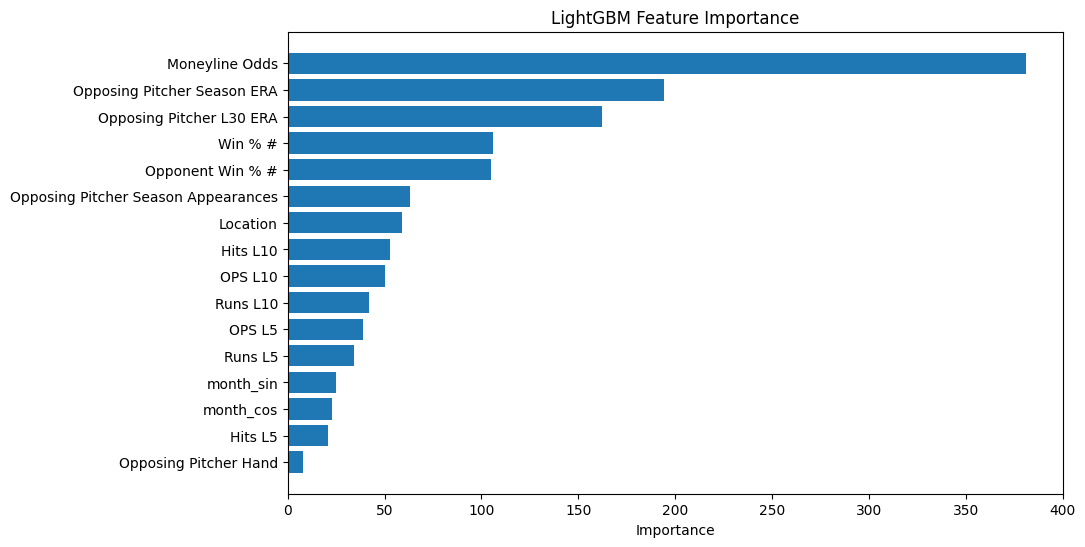

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance values
importances = final_lgb.feature_importances_

# Combine with feature names
feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

# Optional: plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("LightGBM Feature Importance")
plt.show()


In [ ]:
feat_imp_gain = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_lgb.booster_.feature_importance(importance_type="gain")
}).sort_values(by="Importance", ascending=False)

print(feat_imp_gain.head(10))


                                Feature    Importance
2                        Moneyline Odds  90899.053963
4           Opposing Pitcher Season ERA  20297.988764
7              Opposing Pitcher L30 ERA  15345.929523
3                      Opponent Win % #  10510.325722
0                               Win % #   8561.513300
1                              Location   6524.483273
12                             Hits L10   5541.510906
13                              OPS L10   5331.916821
6   Opposing Pitcher Season Appearances   4857.867081
10                               OPS L5   3016.559517


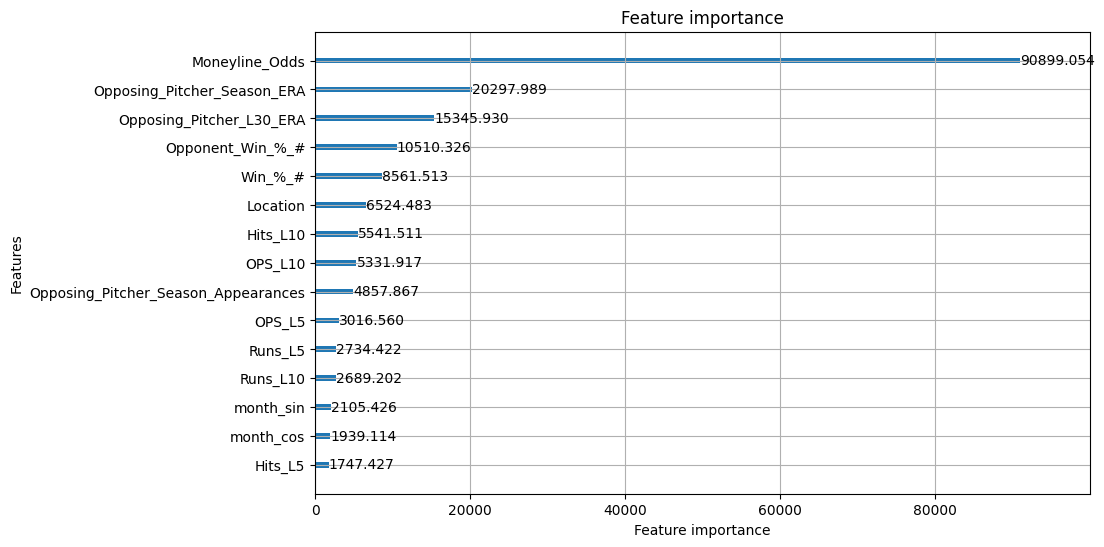

In [ ]:
import lightgbm as lgb

lgb.plot_importance(final_lgb, importance_type="gain", max_num_features=15, figsize=(10,6))
plt.show()


## get data to predict(today)

### get today

In [ ]:
# my_date = datetime(2025, 6, 14)

def get_test(date, df_clean):
    date_str = date.strftime("%m-%d-%Y")
    print(date_str)
    opposing_pitchers, games = get_pitchers(teams, date)
    for pitcher in opposing_pitchers:
        print(pitcher)
    # print(opposing_pitchers)
    # updated_pitchers, invalid_opp_pitchers = get_eras(opposing_pitchers, date)
    # updated_pitchers = []
    # invalid_opp_pitchers = []
    # for p in opposing_pitchers:
    #     if p[7] == 'Nan':
    #         invalid_opp_pitchers.append(p[0])
    #     else:
    #         try:
    #             p[7] = float(p[7])        # try converting
    #         except ValueError:
    #             invalid_opp_pitchers.append(p[0])          # it cannot be a float
    #     updated_pitchers.append(p)
    # print(f"invalid: {invalid_opp_pitchers}")
    # print(f"updated pitchers before: {updated_pitchers}")
    # updated_pitchers_2, invalid_opp_pitchers = get_eras(updated_pitchers, date)
    # print(f"updated pitchers after: {updated_pitchers_2}")
    # print(f"invalid: {invalid_opp_pitchers}")
    # print("done")

    odds = fetch_mlbodds_for_date(date)
    print("________________")
    for odd in odds:
        print(odd)
    # print(odds)
    matchups, doubles, spreads = combine_pitchers_and_odds(opposing_pitchers, odds)


    matchups_w_pitcher_stats_today = get_pitcher_stats(matchups, rolling_innings, date_str)
    print("___________")
    # for match in matchups_w_pitcher_stats_today: # format ['Brewers', '(59-35)', 'A', 'Pirates', '(48-47)', 'Braxton Ashcraft', 'RHP', 3.24, '-103', 18, 4.28]
    #     print(match)

    
    # print(f"date: {date}")
    # print(f"max date: {max(df_clean['Date'])}")
    day_ago_df = df_clean[df_clean['Date'] == (max(df_clean['Date']))]
    games = []
    for match in matchups:
        print(match) # format ['Royals', '(38-57)', 'A', 'Orioles', '(44-51)', 'Brandon Young', 'RHP', 3.42, '+124']
        iter = 2
        while day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).empty:
            print("got here")
            print(match)
            print(iter)
            day_ago_df = df_clean[df_clean['Date'] == (date - timedelta(days=iter))]
            iter += 1
            # continue
        match.append(float(day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).iloc[0]['Next Runs L5']))
        match.append(float(day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).iloc[0]['Next Runs L10']))
        match.append(float(day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).iloc[0]['Next Hits L5']))
        match.append(float(day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).iloc[0]['Next Hits L10']))
        match.append(float(day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).iloc[0]['Next OPS L5']))
        match.append(float(day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).iloc[0]['Next OPS L10']))
        match.append(date)
        # print(match)
    print(f"matchups: {len(matchups)}")

    desired_indices = [17, 0, 1, 2, 8, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16]

    final_matchups = [[row[i] for i in desired_indices] for row in matchups]

    day_entries = pd.DataFrame(final_matchups, columns=['Date', 'Team', 'Win %', 'Location', 'Moneyline Odds', 'Opponent',
                                                    'Opponent Win %','Opposing Pitcher', 'Opposing Pitcher Hand',
                                                    'Opposing Pitcher Season ERA', 'Opposing Pitcher Season Appearances',
                                                    'Opposing Pitcher L30 ERA', 'Runs L5', 'Runs L10', 'Hits L5', 'Hits L10', 'OPS L5', 'OPS L10'])

    print(f"day_entries: {len(day_entries)}")

    print("_________________________")

    for i in range(len(day_entries)):
        record = get_team_record(day_entries.at[i,'Team'], date_str)
        opp_record = get_team_record(day_entries.at[i,'Opponent'], date_str)
        print(f"before: {day_entries.at[i,'Win %']}")
        day_entries.at[i,'Win %'] = record['record']
        day_entries.at[i,'Opponent Win %'] = opp_record['record']
        print(f"after: {day_entries.at[i,'Win %']}, should be {record}")


    print("_________________________")

    for i in range(len(day_entries)):
        # print(day_entries.iloc[i])

        me_lines = re.split(r"[-()]", day_entries.loc[i, 'Win %'])
        opp_lines = re.split(r"[-()]", day_entries.loc[i, 'Opponent Win %'])

        if len(me_lines) < 4:
            if len(opp_lines) < 4:
                continue
            else:
                opp_denom = float(opp_lines[1]) + float(opp_lines[2])

                if opp_denom == 0:
                    day_entries.loc[i,'Opponent Win % #'] = 0
                else:
                    day_entries.loc[i,'Opponent Win % #'] = round(float(opp_lines[1]) / opp_denom, 3)

        else:
            me_denom = float(me_lines[1]) + float(me_lines[2])

            if me_denom == 0:
                day_entries.loc[i,'Win % #'] = 0
            else:
                day_entries.loc[i,'Win % #'] = round(float(me_lines[1]) / me_denom, 3)

            if len(opp_lines) < 4:
                continue
            else:
                opp_denom = float(opp_lines[1]) + float(opp_lines[2])

                if opp_denom == 0:
                    day_entries.loc[i,'Opponent Win % #'] = 0
                else:
                    day_entries.loc[i,'Opponent Win % #'] = round(float(opp_lines[1]) / opp_denom, 3)

    for i in range(len(day_entries)):
        if day_entries.loc[i, 'Location'] == 'H':
            day_entries.loc[i, 'Location'] = 1
        elif day_entries.loc[i, 'Location'] == 'A':
            day_entries.loc[i, 'Location'] = 0

        if day_entries.loc[i, 'Opposing Pitcher Hand'] == 'LHP':
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 1
        elif day_entries.loc[i, 'Opposing Pitcher Hand'] == 'RHP':
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 0
        elif day_entries.loc[i, 'Opposing Pitcher Hand'] == '右投手':
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 0
        elif day_entries.loc[i, 'Opposing Pitcher Hand'] == '左投手':
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 1
        elif day_entries.loc[i, 'Opposing Pitcher Hand'] == 'LD':
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 0
        elif day_entries.loc[i, 'Opposing Pitcher Hand'] == 'LZ':
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 1
        else:
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 0
        

    numeric_cols = [
        'Win % #',
        # 'Score',
        'Moneyline Odds',
        'Opponent Win % #',
        # 'Opposing Pitcher Season ERA',
        # 'Opposing Pitcher Season Appearances',
        # 'Opposing Pitcher L30 ERA',
        'Runs L5',
        'Hits L5',
        'OPS L5',
        'Runs L10',
        'Hits L10',
        'OPS L10'
    ]

    int_cols = ['Location', 'Moneyline Odds', 'Opposing Pitcher Hand','Opposing Pitcher Season Appearances']
    float_cols = ['Win % #', 'Opponent Win % #', 'Opposing Pitcher Season ERA', 'Opposing Pitcher L30 ERA',
                    'Runs L5', 'Hits L5', 'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10']

    print(f"day_entries: {len(day_entries)}")

    df_clean = day_entries.dropna(subset=numeric_cols).copy()
    df_clean.reset_index(drop=True, inplace=True)

    print(f"df_clean: {len(df_clean)}")

    df_clean[int_cols] = (
        df_clean[int_cols]
        .apply(pd.to_numeric, errors="raise")
        .astype("Int64")
    )
    # df_clean[int_cols] = df_clean[int_cols].astype(int)
    df_clean[float_cols] = df_clean[float_cols].astype(float)

    df_clean['Date'] = pd.to_datetime(df_clean['Date'])


    df_clean['month_sin']  = np.sin(2 * np.pi * df_clean['Date'].dt.month  / 12)
    df_clean['month_cos']  = np.cos(2 * np.pi * df_clean['Date'].dt.month  / 12)

    games = df_clean['Team'].values


    keep_cols_day = ['Win % #', 'Location', 'Moneyline Odds', 'Opponent Win % #',
                'Opposing Pitcher Season ERA','Opposing Pitcher Hand',
                'Opposing Pitcher Season Appearances', 'Opposing Pitcher L30 ERA',
                'Runs L5', 'Hits L5', 'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10',
                'month_sin', 'month_cos']
    df_red = df_clean[keep_cols_day]

    return df_red, games, invalid_opp_pitchers, spreads


day_df, games, invalid_opp_pitchers, spreads = get_test(date_to_predict, df_clean)
day_df


06-16-2026
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
['Marlins', '(36-38)', 'A', 'Phillies', '(40-33)', 'Jesús Luzardo', 'LHP', '4.20']
['Phillies', '(40-33)', 'H', 'Marlins', '(36-38)', 'Tyler Phillips', 'RHP', '3.10']
['Royals', '(29-45)', 'A', 'Nationals', '(39-35)', 'Foster Griffin', 'LHP', '3.32']
['Nationals', '(39-35)', 'H', 'Royals', '(29-45)', 'Michael Wacha', 'RHP', '3.64']
['Blue Jays', '(35-38)', 'A', 'Red Sox', '(29-41)', 'Payton Tolle', 'LHP', '2.93']
['Red Sox', '(29-41)', 'H', 'Blue Jays', '(35-38)', 'Dylan Cease', 'RHP', '2.71']
['White Sox', '(38-33)', 'A', 'Yankees', '(44-27)', 'Gerrit Cole', 'RHP', '2.57']
['Yankees', '(44-27)', 'H', 'White Sox', '(38-33)', 'Davis Martin', 'RHP', '3.31']
['Mets', '(32-41)', 'A', 'Reds', '(35-37)', 'Brady Singer', 'RHP', '5.32']
['Reds', '(35-37)', 'H', 'Mets', '(32-41)', 'Kodai Senga', 'RHP', '9.00']
['Giants', '(30-43)', 'A', 'Braves', '(46-26)', 'Grant Holmes', 'RHP', '4.33']
['Braves', '(46-26)', 

,Win % #,Location,Moneyline Odds,Opponent Win % #,Opposing Pitcher Season ERA,Opposing Pitcher Hand,Opposing Pitcher Season Appearances,Opposing Pitcher L30 ERA,Runs L5,Hits L5,OPS L5,Runs L10,Hits L10,OPS L10,month_sin,month_cos
0,0.493,0,153,0.542,4.35,1,14,2.57,2.2,8.0,0.6040,3.1,8.5,0.6632,1.224647e-16,-1.0
1,0.542,1,-186,0.493,1.86,0,19,2.10,5.0,10.4,0.7692,5.4,9.5,0.7527,1.224647e-16,-1.0
2,0.397,0,119,0.521,3.46,1,14,5.46,3.2,7.4,0.5838,3.8,8.4,0.6566,1.224647e-16,-1.0
3,0.521,1,-143,0.397,3.58,0,14,4.99,5.2,9.6,0.7910,5.8,10.0,0.7602,1.224647e-16,-1.0
4,0.472,0,-120,0.420,2.70,1,9,3.23,2.0,6.8,0.6048,3.3,8.3,0.6800,1.224647e-16,-1.0
5,0.420,1,100,0.472,2.91,0,12,2.95,4.2,8.4,0.7306,5.6,9.5,0.8332,1.224647e-16,-1.0
6,0.543,0,124,0.614,2.45,0,4,1.67,4.0,7.8,0.6306,3.6,7.6,0.6281,1.224647e-16,-1.0
7,0.614,1,-149,0.543,2.41,0,13,3.41,5.0,7.8,0.6730,4.2,7.1,0.6235,1.224647e-16,-1.0
8,0.444,0,-117,0.479,5.61,0,13,6.19,3.8,8.4,0.6880,4.4,7.6,0.7069,1.224647e-16,-1.0
9,0.479,1,-103,0.444,9.00,0,5,8.55,5.8,8.0,0.8202,5.0,7.7,0.7530,1.224647e-16,-1.0


In [ ]:
# day_df.loc[0, 'Opposing Pitcher ERA'] = 
# day_df.loc[1, 'Opposing Pitcher ERA'] = 7.07
# day_df.loc[2, 'Opposing Pitcher ERA'] = 6.23
# day_df.loc[3, 'Opposing Pitcher ERA'] = 2.81
# day_df.loc[4, 'Opposing Pitcher ERA'] = 5.14
# day_df.loc[5, 'Opposing Pitcher ERA'] = 1.53
# day_df.loc[6, 'Opposing Pitcher ERA'] = 3.31
# day_df.loc[7, 'Opposing Pitcher ERA'] = 4.30
# day_df.loc[8, 'Opposing Pitcher ERA'] = 6.75
# day_df.loc[9, 'Opposing Pitcher ERA'] = 3.24
# day_df.loc[10, 'Opposing Pitcher ERA'] = 1.02
# day_df.loc[11, 'Opposing Pitcher ERA'] = 6.14
# day_df.loc[12, 'Opposing Pitcher ERA'] = 0.73
# day_df.loc[13, 'Opposing Pitcher ERA'] = 2.45
# day_df.loc[14, 'Opposing Pitcher ERA'] = 3.60
# day_df.loc[15, 'Opposing Pitcher ERA'] = 
# day_df.loc[16, 'Opposing Pitcher ERA'] = 
# day_df.loc[24, 'Opposing Pitcher ERA'] = 5.27
# day_df.loc[25, 'Opposing Pitcher ERA'] = 0.50
# day_df.loc[26, 'Opposing Pitcher ERA'] = 9.45
# day_df.loc[27, 'Opposing Pitcher ERA'] = 5.74
# day_df.loc[28, 'Opposing Pitcher ERA'] = 4.60
# day_df.loc[29, 'Opposing Pitcher ERA'] = 2.63

# day_df['Win % #'] = 0
# day_df['Opponent Win % #'] = 0

day_df

,Win % #,Location,Moneyline Odds,Opponent Win % #,Opposing Pitcher Season ERA,Opposing Pitcher Hand,Opposing Pitcher Season Appearances,Opposing Pitcher L30 ERA,Runs L5,Hits L5,OPS L5,Runs L10,Hits L10,OPS L10,month_sin,month_cos
0,0.493,0,153,0.542,4.35,1,14,2.57,2.2,8.0,0.6040,3.1,8.5,0.6632,1.224647e-16,-1.0
1,0.542,1,-186,0.493,1.86,0,19,2.10,5.0,10.4,0.7692,5.4,9.5,0.7527,1.224647e-16,-1.0
2,0.397,0,119,0.521,3.46,1,14,5.46,3.2,7.4,0.5838,3.8,8.4,0.6566,1.224647e-16,-1.0
3,0.521,1,-143,0.397,3.58,0,14,4.99,5.2,9.6,0.7910,5.8,10.0,0.7602,1.224647e-16,-1.0
4,0.472,0,-120,0.420,2.70,1,9,3.23,2.0,6.8,0.6048,3.3,8.3,0.6800,1.224647e-16,-1.0
5,0.420,1,100,0.472,2.91,0,12,2.95,4.2,8.4,0.7306,5.6,9.5,0.8332,1.224647e-16,-1.0
6,0.543,0,124,0.614,2.45,0,4,1.67,4.0,7.8,0.6306,3.6,7.6,0.6281,1.224647e-16,-1.0
7,0.614,1,-149,0.543,2.41,0,13,3.41,5.0,7.8,0.6730,4.2,7.1,0.6235,1.224647e-16,-1.0
8,0.444,0,-117,0.479,5.61,0,13,6.19,3.8,8.4,0.6880,4.4,7.6,0.7069,1.224647e-16,-1.0
9,0.479,1,-103,0.444,9.00,0,5,8.55,5.8,8.0,0.8202,5.0,7.7,0.7530,1.224647e-16,-1.0


In [ ]:
games

array(['Marlins', 'Phillies', 'Royals', 'Nationals', 'Blue Jays',
       'Red Sox', 'White Sox', 'Yankees', 'Mets', 'Reds', 'Giants',
       'Braves', 'Guardians', 'Brewers', 'Padres', 'Cardinals', 'Twins',
       'Rangers', 'Rockies', 'Cubs', 'Tigers', 'Astros', 'Orioles',
       'Mariners', 'Pirates', 'Athletics', 'Angels', 'Diamondbacks',
       'Rays', 'Dodgers'], dtype=object)

In [ ]:

X_new = day_df

y_pred_new = final_lgb.predict(X_new)
print(len(games))
print(date_to_predict.strftime("%m-%d-%y"))
game_indicator = 0
for i in range(len(games)-1):
    if game_indicator == 0:
        game_indicator = 1
        print(f"Game: {games[i]} vs {games[i+1]}")
        print(f"\t{round(y_pred_new[i].item(), 3)} to {round(y_pred_new[i+1].item(), 3)}")
    else:
        game_indicator = 0


[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
30
06-16-26
Game: Marlins vs Phillies
	4.021 to 4.718
Game: Royals vs Nationals
	4.35 to 4.588
Game: Blue Jays vs Red Sox
	4.367 to 4.386
Game: White Sox vs Yankees
	4.307 to 4.493
Game: Mets vs Reds
	4.518 to 4.596
Game: Giants vs Braves
	4.223 to 5.176
Game: Guardians vs Brewers
	4.454 to 4.794
Game: Padres vs Cardinals
	4.379 to 4.389
Game: Twins vs Rangers
	4.415 to 4.578
Game: Rockies vs Cubs
	4.157 to 5.105
Game: Tigers vs Astros
	3.933 to 4.795
Game: Orioles vs Mariners
	4.304 to 4.614
Game: Pirates vs Athletics
	4.46 to 4.56
Game: Angels vs Diamondbacks
	4.601 to 4.461
Game: Rays vs Dodgers
	4.32 to 4.513


In [ ]:
df_clean.size

425698

In [ ]:
# pick_a_date = datetime(2025, 6, 19)
# pick_a_day_df = df_clean[df_clean['Date'] == pick_a_date]
# pick_a_day_df


### predict wins

In [ ]:
use_data_date = date_to_add
copy_df = pd.read_csv(f"daily_entries_fixed/fixed_entries_{use_data_date.strftime("%y_%m_%d")}.csv")
# copy_df = pd.read_csv("era_record_entries_11.csv")

In [ ]:
copied = copy_df.sort_values(['Team', 'Date'])

# 3) Compute L5 and L10 by grouping on Team:
copied['Runs L5'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(1)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['Hits L5'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(1)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['OPS L5'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(1)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)


copied['Runs L10'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(1)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['Hits L10'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(1)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['OPS L10'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(1)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

# 3) Compute L5 and L10 by grouping on Team:
copied['Next Runs L5'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(0)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['Next Hits L5'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(0)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['Next OPS L5'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(0)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)


copied['Next Runs L10'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(0)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['Next Hits L10'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(0)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['Next OPS L10'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(0)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)


df = copied[['Date', 'Team', 'Win % #', 'Score', 'Location', 'Moneyline Odds',
        'Opponent', 'Opponent Win % #',
        'Opposing Pitcher Season ERA', 'Opposing Pitcher Hand',
        'Opposing Pitcher Season Appearances', 'Opposing Pitcher L30 ERA',
        'Runs L5', 'Hits L5', 'OPS L5',
        'Runs L10', 'Hits L10', 'OPS L10',
        'Next Runs L5', 'Next Runs L10', 'Next Hits L5',
        'Next Hits L10', 'Next OPS L5', 'Next OPS L10']]
df

numeric_cols = [
    'Win % #',
    'Score',
    'Moneyline Odds',
    'Opponent Win % #',
    'Opposing Pitcher Season ERA',
    'Opposing Pitcher Season Appearances',
    'Opposing Pitcher L30 ERA',
    'Runs L5',
    'Hits L5',
    'OPS L5',
    'Runs L10',
    'Hits L10',
    'OPS L10',
    'Next Runs L5', 'Next Runs L10', 'Next Hits L5',
    'Next Hits L10', 'Next OPS L5', 'Next OPS L10'
]

int_cols = ['Score', 'Location', 'Moneyline Odds', 'Opposing Pitcher Season Appearances', 'Opposing Pitcher Hand']
float_cols = ['Win % #', 'Opponent Win % #', 'Opposing Pitcher Season ERA', 'Opposing Pitcher L30 ERA', 'Runs L5',
                'Hits L5', 'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10',
                'Next Runs L5', 'Next Runs L10', 'Next Hits L5',
                'Next Hits L10', 'Next OPS L5', 'Next OPS L10']

df_clean = df.dropna(subset=numeric_cols).copy()
df_clean.reset_index(drop=True, inplace=True)

df_clean[int_cols] = df_clean[int_cols].astype(int)
df_clean[float_cols] = df_clean[float_cols].astype(float)

df_clean['Date'] = pd.to_datetime(df_clean['Date'])


df_clean['month_sin']  = np.sin(2 * np.pi * df_clean['Date'].dt.month  / 12)
df_clean['month_cos']  = np.cos(2 * np.pi * df_clean['Date'].dt.month  / 12)



In [ ]:
df_map = (
    df_clean[['Date','Team','Score']]
    .rename(columns={
        'Team':'Opponent',
        'Score':'Opponent Score'
    })
)

df_wins = df_clean.merge(
    df_map,
    on=['Date','Opponent'],
    how='left'
)

df_wins["Win"] = (df_wins["Score"] > df_wins["Opponent Score"]).astype(int)

In [ ]:
df_wins_red = pd.get_dummies(
    df_wins,
    columns=['Team', 'Opponent'],
    prefix=['Team', 'Opp'],
    drop_first=True
)

keep_cols_win = ['Win % #', 'Score', 'Win', 'Location', 'Moneyline Odds', 'Opponent Win % #',
            'Opposing Pitcher Season ERA', 'Opposing Pitcher Hand',
            'Opposing Pitcher Season Appearances', 'Opposing Pitcher L30 ERA',
            'Runs L5', 'Hits L5', 'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10',
            'month_sin', 'month_cos']

df_wins_red = df_wins_red[keep_cols_win]
df_wins_red.size
len(df_wins_red)


15573

In [ ]:
X_win = df_wins_red.drop(columns=['Score', 'Win'])

y_win = df_wins_red["Win"]

X_train_win, X_test_win, y_train_win, y_test_win = train_test_split(
    X_win, y_win, test_size=0.20, random_state=42, stratify=y_win
)


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, roc_auc_score
import numpy as np


In [ ]:
best_params_win =  {'bagging_fraction': 0.6, 'bagging_freq': 0, 'feature_fraction': 0.6, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}

# best_params_win = {'bagging_fraction': 0.4, 'bagging_freq': 0, 'feature_fraction': 0.4, 'learning_rate': 0.005, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}

final_win_lgb = LGBMClassifier(**best_params_win)

final_win_lgb.fit(X_train_win, y_train_win)

[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Info] Number of positive: 6081, number of negative: 6377
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000398 seconds.
You can set `force_col_wise=true` to remove the o

LGBMClassifier(bagging_fraction=0.6, bagging_freq=0, feature_fraction=0.6,
               learning_rate=0.01, max_depth=5)

                                Feature  Importance
2                        Moneyline Odds         400
0                               Win % #         294
3                      Opponent Win % #         250
4           Opposing Pitcher Season ERA         229
12                             Hits L10         220
13                              OPS L10         217
7              Opposing Pitcher L30 ERA         212
9                               Hits L5         198
10                               OPS L5         174
11                             Runs L10         127
6   Opposing Pitcher Season Appearances         124
8                               Runs L5         103
1                              Location          57
14                            month_sin          32
15                            month_cos          25


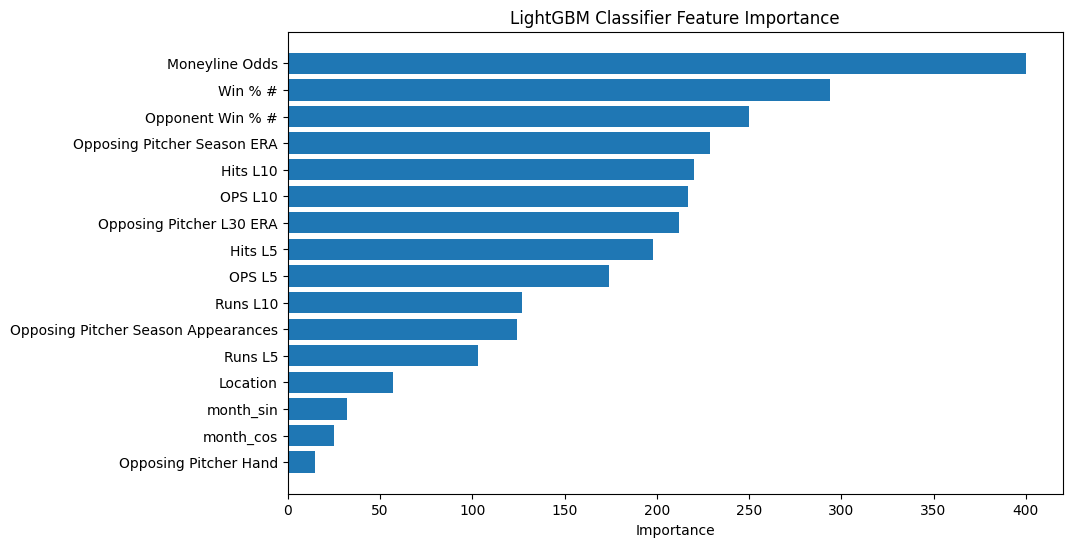

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = final_win_lgb.feature_importances_

# Combine with feature names
feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp.head(15))

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("LightGBM Classifier Feature Importance")
plt.show()


In [ ]:
feat_imp_gain = pd.DataFrame({
    "Feature": X_train.columns,
    "GainImportance": final_win_lgb.booster_.feature_importance(importance_type="gain"),
    "SplitImportance": final_win_lgb.booster_.feature_importance(importance_type="split")
}).sort_values(by="GainImportance", ascending=False)

print(feat_imp_gain.head(10))


                        Feature  GainImportance  SplitImportance
2                Moneyline Odds    14095.676322              400
0                       Win % #     2697.829013              294
3              Opponent Win % #     2253.191254              250
4   Opposing Pitcher Season ERA     1442.620212              229
12                     Hits L10     1340.992799              220
13                      OPS L10     1261.566398              217
7      Opposing Pitcher L30 ERA     1203.359391              212
9                       Hits L5     1070.139605              198
10                       OPS L5      996.192121              174
1                      Location      902.076980               57


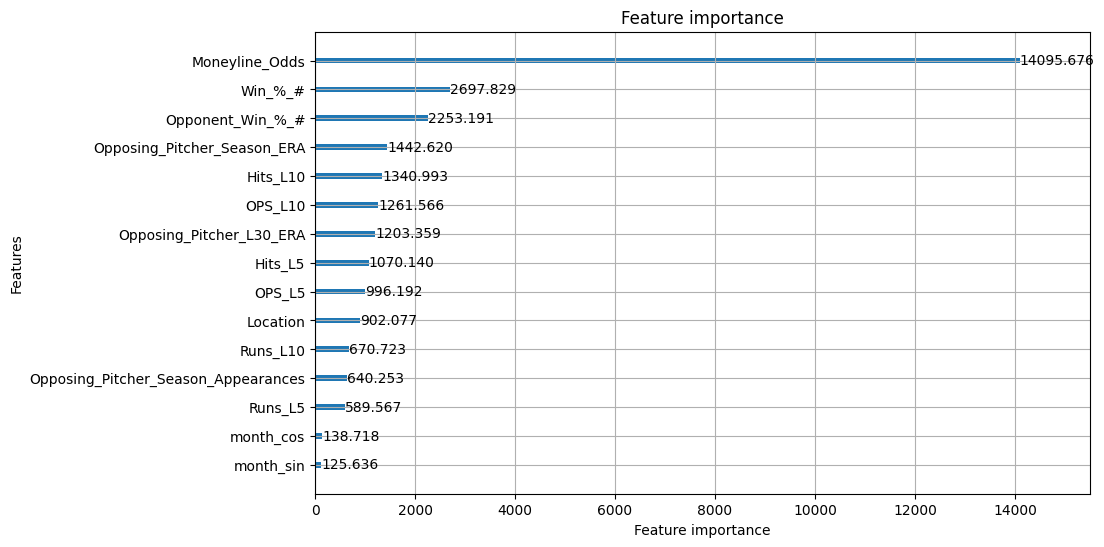

In [ ]:
import lightgbm as lgb

lgb.plot_importance(final_win_lgb, importance_type="gain", max_num_features=15, figsize=(10,6))
plt.show()


In [ ]:
# pred_date = datetime(2025, 7, 1)
pred_date = date_to_predict
day_df_win, games_win, invalid_opps, spreads = get_test(pred_date, df_clean)
# day_df_win

06-16-2026
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
['Marlins', '(36-38)', 'A', 'Phillies', '(40-33)', 'Jesús Luzardo', 'LHP', '4.20']
['Phillies', '(40-33)', 'H', 'Marlins', '(36-38)', 'Tyler Phillips', 'RHP', '3.10']
['Royals', '(29-45)', 'A', 'Nationals', '(39-35)', 'Foster Griffin', 'LHP', '3.32']
['Nationals', '(39-35)', 'H', 'Royals', '(29-45)', 'Michael Wacha', 'RHP', '3.64']
['Blue Jays', '(35-38)', 'A', 'Red Sox', '(29-41)', 'Payton Tolle', 'LHP', '2.93']
['Red Sox', '(29-41)', 'H', 'Blue Jays', '(35-38)', 'Dylan Cease', 'RHP', '2.71']
['White Sox', '(38-33)', 'A', 'Yankees', '(44-27)', 'Gerrit Cole', 'RHP', '2.57']
['Yankees', '(44-27)', 'H', 'White Sox', '(38-33)', 'Davis Martin', 'RHP', '3.31']
['Mets', '(32-41)', 'A', 'Reds', '(35-37)', 'Brady Singer', 'RHP', '5.32']
['Reds', '(35-37)', 'H', 'Mets', '(32-41)', 'Kodai Senga', 'RHP', '9.00']
['Giants', '(30-43)', 'A', 'Braves', '(46-26)', 'Grant Holmes', 'RHP', '4.33']
['Braves', '(46-26)', 

In [ ]:
# day_df_win.loc[0, 'Opposing Pitcher ERA'] = 3.65
# day_df_win.loc[1, 'Opposing Pitcher ERA'] = 2.96
# day_df_win.loc[2, 'Opposing Pitcher ERA'] = 3.59
# day_df_win.loc[3, 'Opposing Pitcher ERA'] = 4.54
# day_df_win.loc[4, 'Opposing Pitcher ERA'] = 5.36
# day_df_win.loc[5, 'Opposing Pitcher ERA'] = 4.98
# day_df_win.loc[6, 'Opposing Pitcher ERA'] = 2.58
# day_df_win.loc[7, 'Opposing Pitcher ERA'] = 4.67
# day_df_win.loc[8, 'Opposing Pitcher ERA'] = 3.94
# day_df_win.loc[9, 'Opposing Pitcher ERA'] = 3.99
# day_df_win.loc[10, 'Opposing Pitcher ERA'] = 3.44
# day_df_win.loc[11, 'Opposing Pitcher ERA'] = 3.66
# day_df_win.loc[12, 'Opposing Pitcher ERA'] = 4.21
# day_df_win.loc[13, 'Opposing Pitcher ERA'] = 3.06
# day_df_win.loc[14, 'Opposing Pitcher ERA'] = 2.82
# day_df_win.loc[15, 'Opposing Pitcher ERA'] = 3.39
# day_df.loc[16, 'Opposing Pitcher ERA'] = 2.50
# day_df.loc[17, 'Opposing Pitcher ERA'] = 1.73
# day_df.loc[18, 'Opposing Pitcher ERA'] = 2.49
# day_df.loc[19, 'Opposing Pitcher ERA'] = 4.83
# day_df.loc[20, 'Opposing Pitcher ERA'] = 3.44
# day_df.loc[21, 'Opposing Pitcher ERA'] = 4.24

# day_df_win['Win % #'] = 0
# day_df_win['Opponent Win % #'] = 0

## score diff based on odds

In [ ]:
import math
from math import exp, factorial, sqrt
from mpmath import besseli

# Poisson CDF: P(T <= k)
def pois_cdf(k, lam):
    return exp(-lam) * sum(lam**i / factorial(i) for i in range(k+1))

def infer_S_from_total(total_line, p_over, p_under):
    # map "Over x.5" -> P(T >= ceil(x.5)) = p_over
    k = math.floor(total_line) + 1  # e.g., 7.5 -> k=8

    # binary search for S
    lo, hi = 0.1, 20.0
    for _ in range(60):
        mid = (lo + hi) / 2
        p_tail = 1 - pois_cdf(k-1, mid)  # P(T >= k)
        if p_tail < p_over:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

def skellam_pmf(k, l1, l2):
    return exp(-(l1+l2)) * (l1/l2)**(k/2) * float(besseli(abs(k), 2*sqrt(l1*l2)))

def P_D_gt_0(mu, S):
    l1, l2 = (S+mu)/2, (S-mu)/2
    s, k = 0.0, 1
    while True:
        t = skellam_pmf(k, l1, l2)
        s += t
        if t < 1e-12 and k > 50: break
        k += 1
    return s

def devig_odds(odds1, odds2):
    odds1_num = int(odds1)
    odds1_exp = -odds1_num / (-odds1_num+100) if odds1_num < 0 else 100/(odds1_num+100)
    odds2_num = int(odds2)
    odds2_exp = -odds2_num / (-odds2_num+100) if odds2_num < 0 else 100/(odds2_num+100)

    odds1_revig = round(odds1_exp / (odds1_exp+odds2_exp), 3)
    odds2_revig = round(odds2_exp / (odds1_exp+odds2_exp), 3)

    return odds1_revig, odds2_revig

def expected_scores(away_odds, home_odds):
    # 0: team
    # 1: ml
    # 2: spread
    # 3: spread odds
    # 4: total line
    # 5: over total odds
    # 6: under total odds

    away_devig, home_devig = devig_odds(away_odds[1], home_odds[1])
    fav_devig = away_devig if away_devig > home_devig else home_devig

    over_devig, under_devig = devig_odds(away_odds[5], away_odds[6])

    S = infer_S_from_total(float(away_odds[4]), over_devig, under_devig)

    lo, hi = -S + 1e-6, S - 1e-6        # mu bounds
    for _ in range(60):                  # bisection on mu
        mid = (lo + hi) / 2
        if P_D_gt_0(mid, S) < fav_devig:
            lo = mid
        else:
            hi = mid
    mu = (lo + hi) / 2

    if fav_devig == away_devig:
        return round((S + mu)/2, 3), round((S - mu)/2, 3), round(mu, 3)
    elif fav_devig == home_devig:
        return round((S - mu)/2, 3), round((S + mu)/2, 3), round(-mu, 3)

# predictions

### score and wins

In [ ]:

X_new = day_df

y_pred_new = final_lgb.predict(X_new)
print(len(games))
print(date_to_predict.strftime("%m-%d-%y"))
for i in range(0, len(games)-1, 2):
    away = games[i]
    home = games[i+1]
    away_pred = round(y_pred_new[i].item(), 3)
    home_pred = round(y_pred_new[i+1].item(), 3)
    # print(f"Game: {away} @ {home}")
    # print(f"\t{away_pred} to {home_pred}")
    away_spread = spreads[i]
    home_spread = spreads[i+1]

    winner = home if home_pred >= away_pred else away
    # hm, am = _ml_lookup.get((home, away), (None, None))
    # ml = hm if winner == home else am
    if away in invalid_opp_pitchers or home in invalid_opp_pitchers:
        print(f"Pitchers TBD ")
    if winner == home:
        # print(f"Winner: {winner}, Score: {away_pred} to {home_pred} (ML: {day_df['Moneyline Odds'][i+1]})")
        print(f"Game: {away} @ {home}, {away_pred} to {home_pred} (ML: {day_df['Moneyline Odds'][i+1]})")
    elif winner == away:
        # print(f"Winner: {winner}, Score: {away_pred} to {home_pred} (ML: {day_df['Moneyline Odds'][i]})")
        print(f"Game: {away} @ {home}, {away_pred} to {home_pred} (ML: {day_df['Moneyline Odds'][i]})")
    else:
        print(f"Winner: {winner} (ML: N/A)")
    
    print(expected_scores(away_spread, home_spread))
    # print(home_spread)
    print("__________________")




[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
30
06-16-26
Game: Marlins @ Phillies, 4.021 to 4.718 (ML: -186)
(3.592, 5.011, -1.42)
__________________
Game: Royals @ Nationals, 4.35 to 4.588 (ML: -143)
(3.922, 4.903, -0.981)
__________________
Game: Blue Jays @ Red Sox, 4.367 to 4.386 (ML: 100)
(4.132, 3.468, 0.664)
__________________
Game: White Sox @ Yankees, 4.307 to 4.493 (ML: -149)
(3.78, 4.83, -1.05)
__________________
Game: Mets @ Reds, 4.518 to 4.596 (ML: -103)
(5.638, 5.007, 0.631)
__________________
Game: Giants @ Braves, 4.223 to 5.176 (ML: -175)
(4.143, 5.502, -1.359)
__________________
Game: Guardians @ Brewers, 4.454 to 4.794 (ML: -156)
(3.814, 4.944, -1.13)
________________

In [ ]:
X_new_win = day_df_win

y_pred_new_win = final_win_lgb.predict(X_new_win)
y_proba_win = final_win_lgb.predict_proba(X_new_win)
print(pred_date.strftime("%m-%d-%y"))
for i in range(0, len(games_win)-1, 2):
    away_win = games_win[i]
    home_win = games_win[i+1]
    away_prob = (y_proba_win[i][1] + y_proba_win[i+1][0]) / 2
    home_prob = (y_proba_win[i][0] + y_proba_win[i+1][1]) / 2
    # print(f"Game: {away_win} @ {home_win}")
    # team1_prob = (y_proba_win[i][1] + y_proba_win[i+1][0]) / 2
    # team2_prob = (y_proba_win[i][0] + y_proba_win[i+1][1]) / 2
    if away_prob > home_prob:
        print(f"Winner: {away_win}, Conf: {round(away_prob*100, 2)} (ML: {day_df_win['Moneyline Odds'][i]})")
    elif away_prob < home_prob:
        print(f"Winner: {home_win}, Conf: {round(home_prob*100, 2)} (ML: {day_df_win['Moneyline Odds'][i+1]})")
    else:
        print("uhoh")
    print("__________________")


[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
06-16-26
Winner: Phillies, Conf: 55.99 (ML: -186)
__________________
Winner: Nationals, Conf: 53.15 (ML: -143)
__________________
Winner: Red Sox, Conf: 50.37 (ML: 100)
__________________
Winner: Yankees, Conf: 52.99 (ML: -149)
__________________
Winner: Mets, Conf: 50.24 (ML: -117)
__________________

## all predictions

In [ ]:
from termcolor import colored
# run predictions: y_pred_new
# win predictions: y_proba_win
bets = []
best_bets = []
errors = []
this_date = pred_date.strftime("%m-%d-%y")
print(this_date)
print(f"{int(len(games)/2)} games")
for i in range(0, len(games)-1, 2):
    # teams
    away = games[i]
    home = games[i+1]

    ## odds
    # 0: team
    # 1: ml
    # 2: spread
    # 3: spread odds
    # 4: total line
    # 5: over total odds
    # 6: under total odds
    away_spread = spreads[i]
    home_spread = spreads[i+1]

    # score predictions
    away_score_pred = round(y_pred_new[i].item(), 3)
    home_score_pred = round(y_pred_new[i+1].item(), 3)

    # win probability predictions
    away_win_prob = round(((y_proba_win[i][1] + y_proba_win[i+1][0]) / 2) * 100, 1)
    home_win_prob = round(((y_proba_win[i][0] + y_proba_win[i+1][1]) / 2)  * 100, 1)

    # expected scores
    away_exp_score, home_exp_score, exp_score_diff = expected_scores(away_spread, home_spread)

    # expected win probability
    away_exp_win, home_exp_win = devig_odds(away_spread[1], home_spread[1])
    away_exp_win = round(away_exp_win * 100, 3)
    home_exp_win = round(home_exp_win * 100, 3)

    # calc diffs and totals
    predicted_diff = round(away_score_pred-home_score_pred, 3)
    # exp_diff = round(away_exp_score-home_exp_score, 3)
    predicted_total = round(away_score_pred+home_score_pred, 3)
    exp_total = round(away_exp_score+home_exp_score, 3)
    #{colored(era[1], 'green')}
    print(f"\t\t{away} @ {home}")
    if away in invalid_opp_pitchers or home in invalid_opp_pitchers:
        errors.append([away, home, "tbd"])
        # print(f"Pitchers TBD ")
        # print("________________________________________________________________________________")
        # continue

    print(f"predicted scores:\t\t{away_score_pred} to {home_score_pred}")
    print(f"exp scores:\t\t\t{away_exp_score} to {home_exp_score}")
    # # diffs
    # if abs(predicted_diff) > abs(exp_score_diff):
    #     print(f"predicted vs exp diff:\t\t{predicted_diff} vs {exp_score_diff}\t\t{colored(away if predicted_diff > 0  else home, 'green')} {colored(away_spread[1] if predicted_diff > 0  else home_spread[1], 'green')} {round(predicted_diff - exp_score_diff, 3)}")
    #     bets.append([this_date, away, home, away if predicted_diff > 0  else home, away_spread[1] if predicted_diff > 0  else home_spread[1], abs(predicted_diff), abs(round(predicted_diff - exp_score_diff, 3)), '', '', '', ''])
    # else:
    #     print(f"predicted vs exp diff:\t\t{predicted_diff} vs {exp_score_diff}")
    
    # # win probs
    # if away_win_prob > home_win_prob: # away predicted to win
    #     print(f"\t\t\t{away} win")
    #     if away_win_prob > away_exp_win:
    #         print(f"predicted vs exp win %:\t\t{away_win_prob} % vs {away_exp_win} %\t{colored(away, 'green')} {colored(away_spread[1], 'green')} {round(away_win_prob - away_exp_win, 3)} %")
    #         if len(bets) >= 1:
    #             if bets[-1][1:4] == [away, home, away]:
    #                 bets[-1][7] = away_win_prob
    #                 bets[-1][8] = round(away_win_prob - away_exp_win, 3)
    #             else:
    #                 bets.append([this_date, away, home, away, away_spread[1], '', '', away_win_prob, round(away_win_prob - away_exp_win, 3), '', ''])
    #         else:
    #             bets.append([this_date, away, home, away, away_spread[1], '', '', away_win_prob, round(away_win_prob - away_exp_win, 3), '', ''])
    #     else:
    #         print(f"predicted vs exp win %:\t\t{away_win_prob} % vs {away_exp_win} %")
    # elif away_win_prob < home_win_prob: # home team predicted to win
    #     print(f"\t\t\t{home} win")
    #     if home_win_prob > home_exp_win:
    #         print(f"predicted vs exp win %:\t\t{home_win_prob} % vs {home_exp_win} %\t{colored(home, 'green')} {colored(home_spread[1], 'green')} {round(home_win_prob - home_exp_win, 3)} %")
    #         if len(bets) >= 1:
    #             if bets[-1][1:4] == [away, home, home]:
    #                 bets[-1][7] = home_win_prob
    #                 bets[-1][8] = round(home_win_prob - home_exp_win, 3)
    #             else:
    #                 bets.append([this_date, away, home, home, home_spread[1], '', '', home_win_prob, round(home_win_prob - home_exp_win, 3), '', ''])
    #         else:
    #             bets.append([this_date, away, home, home, home_spread[1], '', '', home_win_prob, round(home_win_prob - home_exp_win, 3), '', ''])
    #     else:
    #         print(f"predicted vs exp win %:\t\t{home_win_prob} % vs {home_exp_win} %")
    # else:
    #     print(f"away predicted vs exp win %:\t\t{away_win_prob} % vs {away_exp_win} %")
    #     print(f"home predicted vs exp win %:\t\t{home_win_prob} % vs {home_exp_win} %")

    # # totals
    # if predicted_total - exp_total > 1:
    #     print(f"predicted vs expected total:\t{predicted_total} vs {exp_total}\t\t{colored("Over", 'green')} {colored(away_spread[4], 'green')} {colored(away_spread[5], 'green')} {round(predicted_total - exp_total, 3)}")
    #     bets.append([this_date, away, home, f"Over {away_spread[4]}", away_spread[5], '', '', '', '',  round(predicted_total - exp_total, 3), ''])
    # elif predicted_total - exp_total < -1:
    #     print(f"predicted vs expected total:\t{predicted_total} vs {exp_total}\t\t{colored("Under", 'green')} {colored(away_spread[4], 'green')} {colored(away_spread[6], 'green')} {round(predicted_total - exp_total, 3)}")
    #     bets.append([this_date, away, home, f"Under {away_spread[4]}", away_spread[6], '', '', '', '', round(predicted_total - exp_total, 3), ''])
    # else:
    #     print(f"predicted vs expected total:\t{predicted_total} vs {exp_total}")

# bet_data = pd.DataFrame(bets, columns=['Date', 'Away Team', 'Home Team', 'Pick', 'Odds', 'Projected Score Diff', 'Score Diff from Expected', 'Projected Win %', 'Win % Diff from Expected', 'Total Diff', 'Result'])
# print(errors)
# print(len(bet_data))
# bet_data

###################################################################################################
    # diffs
    if predicted_diff >= 0:
        print(f"\tscores prediction: {away} win")
        print(f"predicted vs exp diff:\t\t{predicted_diff} vs {exp_score_diff}\t\t{colored(away if predicted_diff > 0  else home, 'green')} {colored(away_spread[1] if predicted_diff > 0  else home_spread[1], 'green')} {round(predicted_diff - exp_score_diff, 3) if exp_score_diff >= 0 else round(predicted_diff + exp_score_diff, 3)}    {"away fav" if exp_score_diff >= 0 else "away dog"}")
        bets.append([this_date, away, home, away if predicted_diff > 0  else home, away_spread[1] if predicted_diff > 0  else home_spread[1], predicted_diff, exp_score_diff, '', '', '', ''])
        ##################
        # best bets
        if exp_score_diff >= 0: # away fav
            if (round(predicted_diff - exp_score_diff, 3) >= away_fav_scores_pred_exp_diff
                    and predicted_diff >= away_fav_scores_pred_diff
                    and exp_score_diff >= away_fav_scores_exp_diff):
                print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
                best_bets.append([this_date, away, home, away if predicted_diff > 0  else home, away_spread[1] if predicted_diff > 0  else home_spread[1], predicted_diff, exp_score_diff, '', '', '', ''])

        else:                   # away dog
            if (round(predicted_diff + exp_score_diff, 3) >= away_dog_scores_pred_exp_diff
                    and predicted_diff >= away_dog_scores_pred_diff
                    and exp_score_diff <= away_dog_scores_exp_diff):
                print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
                best_bets.append([this_date, away, home, away if predicted_diff > 0  else home, away_spread[1] if predicted_diff > 0  else home_spread[1], predicted_diff, exp_score_diff, '', '', '', ''])
    elif predicted_diff <= 0:
        print(f"\tscores prediction: {home} win")
        print(f"predicted vs exp diff:\t\t{predicted_diff} vs {exp_score_diff}\t\t{colored(away if predicted_diff > 0  else home, 'green')} {colored(away_spread[1] if predicted_diff > 0  else home_spread[1], 'green')} {round(predicted_diff - exp_score_diff, 3) if exp_score_diff <= 0 else round(predicted_diff + exp_score_diff, 3)}    {"home fav" if exp_score_diff <= 0 else "home dog"}")
        bets.append([this_date, away, home, away if predicted_diff > 0  else home, away_spread[1] if predicted_diff > 0  else home_spread[1], predicted_diff, exp_score_diff, '', '', '', ''])
        ##################
        # best bets
        if exp_score_diff <= 0: # home fav
            if (round(predicted_diff - exp_score_diff, 3) <= home_fav_scores_pred_exp_diff
                    and predicted_diff <= home_fav_scores_pred_diff
                    and exp_score_diff <= home_fav_scores_exp_diff):
                print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
                best_bets.append([this_date, away, home, away if predicted_diff > 0  else home, away_spread[1] if predicted_diff > 0  else home_spread[1], predicted_diff, exp_score_diff, '', '', '', ''])
        else:                   # home dog
            if (round(predicted_diff + exp_score_diff, 3) <= home_dog_scores_pred_exp_diff
                    and predicted_diff <= home_dog_scores_pred_diff
                    and exp_score_diff >= home_dog_scores_exp_diff):
                print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
                best_bets.append([this_date, away, home, away if predicted_diff > 0  else home, away_spread[1] if predicted_diff > 0  else home_spread[1], predicted_diff, exp_score_diff, '', '', '', ''])
    else:
        print("scores issue")
        errors.append([away, home, 'scores'])

    # win probs
    if away_win_prob > home_win_prob:
        print(f"\twin % prediction: {away} win")
        print(f"predicted vs exp win %:\t\t{away_win_prob} % vs {away_exp_win} %\t{colored(away, 'green')} {colored(away_spread[1], 'green')} {round(away_win_prob - away_exp_win, 3) if away_exp_win >= 50 else round(away_win_prob + away_exp_win, 3)} %    {"away fav" if away_exp_win >= 50 else "away dog"}")
        bets.append([this_date, away, home, away, away_spread[1], '', '', away_win_prob, away_exp_win, '', ''])
        ##################
        # best bets
        if away_exp_win >= 50: # away fav
            if (round(away_win_prob - away_exp_win, 3) >= away_fav_win_pct_pred_exp_diff
                    and away_win_prob >= away_fav_win_pct_pred_diff
                    and away_exp_win >= away_fav_win_pct_exp_diff):
                print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
                best_bets.append([this_date, away, home, away, away_spread[1], '', '', away_win_prob, away_exp_win, '', ''])
        else:                   # away dog
            if (round(away_win_prob + away_exp_win, 3) >= away_dog_win_pct_pred_exp_diff
                    and away_win_prob >= away_dog_win_pct_pred_diff
                    and away_exp_win <= away_dog_win_pct_exp_diff):
                print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
                best_bets.append([this_date, away, home, away, away_spread[1], '', '', away_win_prob, away_exp_win, '', ''])
    elif away_win_prob < home_win_prob:
        print(f"\twin % prediction: {home} win")
        print(f"predicted vs exp win %:\t\t{home_win_prob} % vs {home_exp_win} %\t{colored(home, 'green')} {colored(home_spread[1], 'green')} {round(home_win_prob - home_exp_win, 3) if home_exp_win >= 50 else round(home_win_prob + home_exp_win, 3)} %    {"home fav" if home_exp_win >= 50 else "home dog"}")
        bets.append([this_date, away, home, home, home_spread[1], '', '', home_win_prob, home_exp_win, '', ''])
        ##################
        # best bets
        if home_exp_win >= 50: # home fav
            if (round(home_win_prob - home_exp_win, 3) >= home_fav_win_pct_pred_exp_diff
                    and home_win_prob >= home_fav_win_pct_pred_diff
                    and home_exp_win >= home_fav_win_pct_exp_diff):
                print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
                best_bets.append([this_date, away, home, home, home_spread[1], '', '', home_win_prob, home_exp_win, '', ''])
        else:                   # home dog
            if (round(home_win_prob + home_exp_win, 3) >= home_dog_win_pct_pred_exp_diff
                    and home_win_prob >= home_dog_win_pct_pred_diff
                    and home_exp_win <= home_dog_win_pct_exp_diff):
                print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
                best_bets.append([this_date, away, home, home, home_spread[1], '', '', home_win_prob, home_exp_win, '', ''])
    elif away_win_prob == home_win_prob:
        errors.append([away, home, 'tie on wins'])
        print(away_spread[1])
        print(home_spread[1])
        if int(away_spread[1]) > int(home_spread[1]):
            print(f"\twin % prediction: tie (default: underdog -> {away})")
            print(f"predicted vs exp win %:\t\t{away_win_prob} % vs {away_exp_win} %\t{colored(away, 'green')} {colored(away_spread[1], 'green')} {round(away_win_prob - away_exp_win, 3)} %")
            bets.append([this_date, away, home, away, away_spread[1], '', '', away_win_prob, away_exp_win, '', ''])
        else:
            print(f"\twin % prediction: tie (default: underdog -> {home})")
            print(f"predicted vs exp win %:\t\t{home_win_prob} % vs {home_exp_win} %\t{colored(home, 'green')} {colored(home_spread[1], 'green')} {round(home_win_prob - home_exp_win, 3)} %")
            bets.append([this_date, away, home, home, home_spread[1], '', '', home_win_prob, home_exp_win, '', ''])
    else:
        print(f"win % issue")
        errors.append([away, home, 'win %'])

    # totals
    if predicted_total - exp_total > 0:
        print(f"\ttotal prediction: Over {away_spread[4]}")
        print(f"predicted vs expected total:\t{predicted_total} vs {exp_total}\t\t{colored("Over", 'green')} {colored(away_spread[4], 'green')} {colored(away_spread[5], 'green')} {round(predicted_total - exp_total, 3)}")
        bets.append([this_date, away, home, f"Over {away_spread[4]}", away_spread[5], '', '', '', '',  round(predicted_total - exp_total, 3), ''])
        ##################
        # best bets
        if (away_spread[4] == 7.0 or away_spread[4] == 7.5) and round(predicted_total - exp_total, 3) >= over_7:
            print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
            best_bets.append([this_date, away, home, f"Over {away_spread[4]}", away_spread[5], '', '', '', '',  round(predicted_total - exp_total, 3), ''])
        if (away_spread[4] == 8.0 or away_spread[4] == 8.5) and round(predicted_total - exp_total, 3) >= over_8:
            print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
            best_bets.append([this_date, away, home, f"Over {away_spread[4]}", away_spread[5], '', '', '', '',  round(predicted_total - exp_total, 3), ''])
    elif predicted_total - exp_total < 0:
        print(f"\ttotal prediction: Under {away_spread[4]}")
        print(f"predicted vs expected total:\t{predicted_total} vs {exp_total}\t\t{colored("Under", 'green')} {colored(away_spread[4], 'green')} {colored(away_spread[6], 'green')} {round(predicted_total - exp_total, 3)}")
        bets.append([this_date, away, home, f"Under {away_spread[4]}", away_spread[6], '', '', '', '', round(predicted_total - exp_total, 3), ''])
        ##################
        # best bets
        if (away_spread[4] == 7.0 or away_spread[4] == 7.5) and round(predicted_total - exp_total, 3) <= under_7:
            print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
            best_bets.append([this_date, away, home, f"Under {away_spread[4]}", away_spread[6], '', '', '', '', round(predicted_total - exp_total, 3), ''])
        if (away_spread[4] == 8.0 or away_spread[4] == 8.5) and round(predicted_total - exp_total, 3) <= under_8:
            print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
            best_bets.append([this_date, away, home, f"Under {away_spread[4]}", away_spread[6], '', '', '', '', round(predicted_total - exp_total, 3), ''])
        # if (away_spread[4] == 9.0 or away_spread[4] == 9.5) and round(predicted_total - exp_total, 3) <= under_9:
        #     print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
            # best_bets.append([this_date, away, home, f"Under {away_spread[4]}", away_spread[6], '', '', '', '', round(predicted_total - exp_total, 3), ''])
        # if (away_spread[4] == 10.0 or away_spread[4] == 10.5) and round(predicted_total - exp_total, 3) <= under_10:
        #     print(f"\t\t\t\t\t\t\t{colored("best bet", 'red')}")
        #     best_bets.append([this_date, away, home, f"Under {away_spread[4]}", away_spread[6], '', '', '', '', round(predicted_total - exp_total, 3), ''])
    else:
        print(f"totals issue")
        errors.append([away, home, 'totals'])


    print("________________________________________________________________________________")

bet_data = pd.DataFrame(bets, columns=['Date', 'Away Team', 'Home Team', 'Pick', 'Odds', 'Projected Score Diff', 'Expected Score Diff', 'Projected Win %', 'Expected Win %', 'Total Diff', 'Result'])
print(errors)
print(len(bet_data))
bet_data


06-16-26
15 games
		Marlins @ Phillies
predicted scores:		4.021 to 4.718
exp scores:			3.592 to 5.011
	scores prediction: Phillies win
predicted vs exp diff:		-0.697 vs -1.42		Phillies -186 0.723    home fav
	win % prediction: Phillies win
predicted vs exp win %:		56.0 % vs 62.2 %	Phillies -186 -6.2 %    home fav
	total prediction: Over 8.5
predicted vs expected total:	8.739 vs 8.603		Over 8.5 -106 0.136
							best bet
________________________________________________________________________________
		Royals @ Nationals
predicted scores:		4.35 to 4.588
exp scores:			3.922 to 4.903
	scores prediction: Nationals win
predicted vs exp diff:		-0.238 vs -0.981		Nationals -143 0.743    home fav
	win % prediction: Nationals win
predicted vs exp win %:		53.2 % vs 56.3 %	Nationals -143 -3.1 %    home fav
	total prediction: Over 8.5
predicted vs expected total:	8.938 vs 8.825		Over 8.5 -120 0.113
							best bet
________________________________________________________________________________
		Bl

,Date,Away Team,Home Team,Pick,Odds,Projected Score Diff,Expected Score Diff,Projected Win %,Expected Win %,Total Diff,Result
0,06-16-26,Marlins,Phillies,Phillies,-186,-0.697,-1.42,,,,
1,06-16-26,Marlins,Phillies,Phillies,-186,,,56.0,62.2,,
2,06-16-26,Marlins,Phillies,Over 8.5,-106,,,,,0.136,
3,06-16-26,Royals,Nationals,Nationals,-143,-0.238,-0.981,,,,
4,06-16-26,Royals,Nationals,Nationals,-143,,,53.2,56.3,,
5,06-16-26,Royals,Nationals,Over 8.5,-120,,,,,0.113,
6,06-16-26,Blue Jays,Red Sox,Red Sox,+100,-0.019,0.664,,,,
7,06-16-26,Blue Jays,Red Sox,Red Sox,+100,,,50.4,47.8,,
8,06-16-26,Blue Jays,Red Sox,Over 7.5,-105,,,,,1.153,
9,06-16-26,White Sox,Yankees,Yankees,-149,-0.186,-1.05,,,,


## Best Bets (commented)

In [ ]:
# best_bet_data = pd.DataFrame(best_bets, columns=['Date', 'Away Team', 'Home Team', 'Pick', 'Odds', 'Projected Score Diff', 'Expected Score Diff', 'Projected Win %', 'Expected Win %', 'Total Diff', 'Result'])
# print(this_date)
# print(f"{int(len(games)/2)} games")
# print(f"games w/ error: {errors}")
# print(f"total best picks: {len(best_bet_data)}")
# print(f"# of best bets today: {best_bet_data.groupby(['Pick', 'Odds', 'Home Team']).ngroups}")
# agreed_bets = len(best_bet_data) - best_bet_data.groupby(['Pick', 'Odds', 'Home Team']).ngroups
# print(f"# of 2 model ml best bets today: {agreed_bets}")
# print(f"# of score model only best bets today: {(best_bet_data["Projected Score Diff"] != '').sum() - agreed_bets}")
# print(f"# of win % model only best bets today: {(best_bet_data["Projected Win %"] != '').sum() - agreed_bets}")
# print(f"# of over total runs best bets today: {(best_bet_data["Pick"].str.startswith("Over")).sum()}")
# print(f"# of under total runs best bets today: {(best_bet_data["Pick"].str.startswith("Under")).sum()}")

# best_bet_data

# put data into archive

### adjust yesterday

#### all

In [ ]:
archive = pd.read_csv("all_predictions_fixed.csv")
# del archive['Unnamed: 0']
yesterday_date = date_to_add.strftime("%m-%d-%y")
yesterday = archive[archive['Date'] == yesterday_date]
yesterday = yesterday.reset_index(drop=True)
# print(f"doubles: {doubles}")
# print(f"yesterday from archive: {yesterday}")
print(f"yesterday from today: {yesterday_entries}")
for i in range(len(yesterday)):
    game = yesterday.iloc[i].to_dict()
    
    print(game)
    away_score = int(yesterday_entries.loc[yesterday_entries['Team'] == yesterday.at[i, 'Away Team'], 'Score'].iloc[0])
    home_score = int(yesterday_entries.loc[yesterday_entries['Team'] == yesterday.at[i, 'Home Team'], 'Score'].iloc[0])
    # print(f"{away_score} to {home_score}")
    
    if game['Pick'] == game['Away Team']:
        if away_score > home_score:
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'] == yesterday.at[i, 'Away Team']),
                'Result'] = 'Win'
        else:
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'] == yesterday.at[i, 'Away Team']),
                'Result'] = 'Loss'
    elif game['Pick'] == game['Home Team']:
        if away_score < home_score:
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'] == yesterday.at[i, 'Home Team']),
                'Result'] = 'Win'
        else:
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'] == yesterday.at[i, 'Home Team']),
                'Result'] = 'Loss'
    elif game['Pick'].split()[0] == 'Over':
        if int(away_score) + int(home_score) >= float(game['Pick'].split()[1]):
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'].str.split(n=1).str[0] == 'Over'),
                'Result'] = 'Win'
        else:
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'].str.split(n=1).str[0] == 'Over'),
                'Result'] = 'Loss'
    elif game['Pick'].split()[0] == 'Under':
        if int(away_score) + int(home_score) <= float(game['Pick'].split()[1]):
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'].str.split(n=1).str[0] == 'Under'),
                'Result'] = 'Win'
        else:
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'].str.split(n=1).str[0] == 'Under'),
                'Result'] = 'Loss'
    else:
        print("oops")
    # print(yesterday.iloc[i].to_dict())
    # print("__________________________________")
archive.tail(len(yesterday))

yesterday from today:           Date          Team    Win % Score Location Moneyline Odds  \
0   06-15-2026       Marlins  (36-36)     0        A           +162   
1   06-15-2026      Phillies  (38-33)     7        H           -198   
2   06-15-2026        Royals  (29-43)     3        A           +113   
3   06-15-2026     Nationals  (37-35)     7        H           -136   
4   06-15-2026          Mets  (32-39)     0        A           +113   
5   06-15-2026          Reds  (33-37)    12        H           -136   
6   06-15-2026        Padres  (37-33)     0        A           +125   
7   06-15-2026     Cardinals  (38-31)     3        H           -151   
8   06-15-2026         Twins  (33-40)     4        A           +124   
9   06-15-2026       Rangers  (35-36)     2        H           -149   
10  06-15-2026       Rockies  (27-45)     4        A           +183   
11  06-15-2026          Cubs  (37-35)     5        H           -224   
12  06-15-2026        Tigers  (29-42)     9        A   

,Date,Away Team,Home Team,Pick,Odds,Projected Score Diff,Expected Score Diff,Projected Win %,Expected Win %,Total Diff,Result
1755,06-15-26,Marlins,Phillies,Phillies,-198,-0.982,-1.522,NaN,NaN,NaN,Win
1756,06-15-26,Marlins,Phillies,Phillies,-198,NaN,NaN,56.5,63.5,NaN,Win
1757,06-15-26,Marlins,Phillies,Over 8.0,-108,NaN,NaN,NaN,NaN,0.261,Loss
1758,06-15-26,Royals,Nationals,Nationals,-136,-0.529,-0.908,NaN,NaN,NaN,Win
1759,06-15-26,Royals,Nationals,Nationals,-136,NaN,NaN,53.5,55.1,NaN,Win
1760,06-15-26,Royals,Nationals,Under 9.5,-109,NaN,NaN,NaN,NaN,-0.369,Loss
1761,06-15-26,Mets,Reds,Reds,-136,-0.360,-0.904,NaN,NaN,NaN,Win
1762,06-15-26,Mets,Reds,Reds,-136,NaN,NaN,52.2,55.1,NaN,Win
1763,06-15-26,Mets,Reds,Under 9.0,-121,NaN,NaN,NaN,NaN,-0.538,Loss
1764,06-15-26,Padres,Cardinals,Padres,125,0.021,-1.066,NaN,NaN,NaN,Loss


#### best bets (commented)

In [ ]:
# bb_archive = pd.read_csv("best_bets_redone.csv")
# # del archive['Unnamed: 0']
# yesterday_date = date_to_add.strftime("%m-%d-%y")
# # yesterday_date = date_to_add.strftime("%#m/%#d/%Y")
# yesterday = bb_archive[bb_archive['Date'] == yesterday_date]
# yesterday = yesterday.reset_index(drop=True)
# # print(f"doubles: {doubles}")
# print(f"yesterday from archive: {yesterday}")
# print(f"yesterday from today: {yesterday_entries}")
# for i in range(len(yesterday)):
#     game = yesterday.iloc[i].to_dict()

#     away_score = int(yesterday_entries.loc[yesterday_entries['Team'] == yesterday.at[i, 'Away Team'], 'Score'].iloc[0])
#     home_score = int(yesterday_entries.loc[yesterday_entries['Team'] == yesterday.at[i, 'Home Team'], 'Score'].iloc[0])
#     # print(f"{away_score} to {home_score}")
    
#     if game['Pick'] == game['Away Team']:
#         if away_score > home_score:
#             bb_archive.loc[(bb_archive['Date'] == yesterday_date) &
#                 (bb_archive['Away Team'] == yesterday.at[i, 'Away Team']) &
#                 (bb_archive['Home Team'] == yesterday.at[i, 'Home Team']) &
#                 (bb_archive['Pick'] == yesterday.at[i, 'Away Team']),
#                 'Result'] = 'Win'
#         else:
#             bb_archive.loc[(bb_archive['Date'] == yesterday_date) &
#                 (bb_archive['Away Team'] == yesterday.at[i, 'Away Team']) &
#                 (bb_archive['Home Team'] == yesterday.at[i, 'Home Team']) &
#                 (bb_archive['Pick'] == yesterday.at[i, 'Away Team']),
#                 'Result'] = 'Loss'
#     elif game['Pick'] == game['Home Team']:
#         if away_score < home_score:
#             bb_archive.loc[(bb_archive['Date'] == yesterday_date) &
#                 (bb_archive['Away Team'] == yesterday.at[i, 'Away Team']) &
#                 (bb_archive['Home Team'] == yesterday.at[i, 'Home Team']) &
#                 (bb_archive['Pick'] == yesterday.at[i, 'Home Team']),
#                 'Result'] = 'Win'
#         else:
#             bb_archive.loc[(bb_archive['Date'] == yesterday_date) &
#                 (bb_archive['Away Team'] == yesterday.at[i, 'Away Team']) &
#                 (bb_archive['Home Team'] == yesterday.at[i, 'Home Team']) &
#                 (bb_archive['Pick'] == yesterday.at[i, 'Home Team']),
#                 'Result'] = 'Loss'
#     elif game['Pick'].split()[0] == 'Over':
#         if int(away_score) + int(home_score) >= float(game['Pick'].split()[1]):
#             bb_archive.loc[(bb_archive['Date'] == yesterday_date) &
#                 (bb_archive['Away Team'] == yesterday.at[i, 'Away Team']) &
#                 (bb_archive['Home Team'] == yesterday.at[i, 'Home Team']) &
#                 (bb_archive['Pick'].str.split(n=1).str[0] == 'Over'),
#                 'Result'] = 'Win'
#         else:
#             bb_archive.loc[(bb_archive['Date'] == yesterday_date) &
#                 (bb_archive['Away Team'] == yesterday.at[i, 'Away Team']) &
#                 (bb_archive['Home Team'] == yesterday.at[i, 'Home Team']) &
#                 (bb_archive['Pick'].str.split(n=1).str[0] == 'Over'),
#                 'Result'] = 'Loss'
#     elif game['Pick'].split()[0] == 'Under':
#         if int(away_score) + int(home_score) <= float(game['Pick'].split()[1]):
#             bb_archive.loc[(bb_archive['Date'] == yesterday_date) &
#                 (bb_archive['Away Team'] == yesterday.at[i, 'Away Team']) &
#                 (bb_archive['Home Team'] == yesterday.at[i, 'Home Team']) &
#                 (bb_archive['Pick'].str.split(n=1).str[0] == 'Under'),
#                 'Result'] = 'Win'
#         else:
#             bb_archive.loc[(bb_archive['Date'] == yesterday_date) &
#                 (bb_archive['Away Team'] == yesterday.at[i, 'Away Team']) &
#                 (bb_archive['Home Team'] == yesterday.at[i, 'Home Team']) &
#                 (bb_archive['Pick'].str.split(n=1).str[0] == 'Under'),
#                 'Result'] = 'Loss'
#     else:
#         print("oops")
#     # print(yesterday.iloc[i].to_dict())
#     # print("__________________________________")
# bb_archive.tail(len(yesterday))

### update csv

In [ ]:
a_w_pred = pd.concat([archive, bet_data])
a_w_pred.set_index('Date', inplace=True)
a_w_pred.to_csv("all_predictions_fixed.csv")
print(f"{int(len(yesterday_entries)/2)} games yesterday")
print(f"{int(len(games)/2)} games today")
print(f"{this_date}: {len(archive)} + {len(bet_data)} = {len(a_w_pred)}")
# bet_data.set_index('Date', inplace=True)
# bet_data.to_csv("all_predictions_fixed.csv")
# print(f"{this_date}: {len(bet_data)}")
print(errors)


10 games yesterday
15 games today
06-16-26: 1785 + 45 = 1830
[['Angels', 'Diamondbacks', 'tie on wins']]


In [ ]:
# a_w_pred = pd.concat([archive, bet_data])
# best_bet_data.set_index('Date', inplace=True)
# best_bet_data.to_csv("best_bets.csv")
# print(f"{this_date}: {len(archive)} + {len(bet_data)} = {len(a_w_pred)}")


In [ ]:
# best_bet_keeps = best_bet_data[:3]
# best_bet_keeps

In [ ]:
# bb_arch = pd.read_csv("best_bets_fixed.csv")
# bb_new = pd.concat([bb_archive, best_bet_data])
# bb_new.set_index('Date', inplace=True)
# bb_new.to_csv("best_bets_fixed.csv")
# print(f"{this_date}: {len(bb_archive)} + {len(best_bet_data)} = {len(bb_new)}")
# # print(f"{this_date}: {len(best_bet_data)}")


In [ ]:
# pitchers tbd
# twins @ athletics 06/04/25
# braves @ athletics 07/12/25
# athletics @ pirates 8/20/21

# no total
# twins @ reds 06/18/25
# blue jays @ white sox 7/8/25


In [ ]:
temp = pd.read_csv("all_predictions_fixed.csv")

# Save as Excel
temp.to_excel("all_predictions_fixed.xlsx", index=False)


# Send to discord (commented)

In [ ]:
# best_bet_data.to_csv("yesterday_new.csv")

In [ ]:
# msg = f"Best Bets {this_date} (updated dataset): \n\n"
# prev_home_team = None
# for index, row in best_bet_data.iterrows():
#     # print(index, row["column_name"])
#     home_team = row["Home Team"]
#     if home_team != prev_home_team:
#         msg += f"{row["Away Team"]} @ {row["Home Team"]}: \n"
#     msg += f"\t{row["Pick"]}\t{row["Odds"]}\n"
#     if row["Projected Score Diff"] != "":
#         msg += f"\t\tProjected Score Diff: {row["Projected Score Diff"]}\n"
#         msg += f"\t\tExpected Score Diff: {row["Expected Score Diff"]}\n"
#     if row["Projected Win %"] != "":
#         msg += f"\t\tProjected Win %: {row["Projected Win %"]}\n"
#         msg += f"\t\tExpected Win %: {row["Expected Win %"]}\n"
#     if row["Total Diff"] != "":
#         msg += f"\t\tTotal Diff: {row["Total Diff"]}\n"
#     prev_home_team = home_team
# print(msg)

In [ ]:
# webhook_url = "https://discord.com/api/webhooks/1508705616171106374/QTC0xGUiBqQHkdv1iz26kiNogZMBSpEmEBEZiC0X6OaEv7XZoiDlV0QnqcBEgueIcUdD"

# data = {
#     "content": msg
# }

# requests.post(webhook_url, json=data)

### pick a date

In [ ]:
# pick_a_date = datetime(2025, 7, 19)
# pick_a_day_df = df_clean[df_clean['Date'] == pick_a_date]
# # pick_a_day_df = get_for_date(my_date)
# pick_a_day_df
